In [1]:
import os
import glob
import re
import xarray as xr

# ============================================================
# Settings
# ============================================================
nc_dir = (
    "/nird/datalake/NS11071K/users/yongyub/LIM_Output_2026_6_nc"
)

# ============================================================
# Helper functions
# ============================================================
def get_ensemble_number(path):
    """Extract ensemble number from filename."""
    fname = os.path.basename(path)
    m = re.search(r"No_(\d+)", fname)
    if m is None:
        raise ValueError(f"Cannot find ensemble number from {fname}")
    return int(m.group(1))


def open_cesm2_group(nstate, period):
    """
    Open CESM2 LIM NetCDF files as one xarray Dataset.

    Output dims:
      ensemble, state_i, state_j, month, lead_index
    """
    pattern = os.path.join(
        nc_dir,
        f"CESM2_n{nstate}_config_No_*_{period}.nc"
    )

    files = sorted(glob.glob(pattern), key=get_ensemble_number)

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {pattern}")

    ens = [get_ensemble_number(f) for f in files]

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim=xr.DataArray(ens, dims="ensemble", name="ensemble"),
        parallel=False,
        decode_times=False
    )

    return ds


def open_obs_file(nstate, period="1998_2023"):
    """Open one OBS LIM NetCDF file."""
    path = os.path.join(
        nc_dir,
        f"OBS_n{nstate}_config_No_1_{period}.nc"
    )

    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    ds = xr.open_dataset(path, decode_times=False)

    return ds

In [2]:
# ============================================================
# Load CESM2 datasets
# ============================================================
ds_cesm2_n2_1955_2020 = open_cesm2_group(2, "1955_2020")

ds_cesm2_n4_1955_2020 = open_cesm2_group(4, "1955_2020")
ds_cesm2_n4_1998_2020 = open_cesm2_group(4, "1998_2020")

ds_cesm2_n5_1955_2020 = open_cesm2_group(5, "1955_2020")

# ============================================================
# Load OBS datasets
# ============================================================
ds_obs_n2_1998_2023 = open_obs_file(2)
ds_obs_n4_1998_2023 = open_obs_file(4)

In [3]:
ds_cesm2_n5_1955_2020

<xarray.Dataset>
Dimensions:              (state_i: 5, state_j: 5, month: 12, lead_index: 7,
                          ensemble: 50)
Coordinates:
  * state_i              (state_i) float64 1.0 2.0 3.0 4.0 5.0
  * state_j              (state_j) float64 1.0 2.0 3.0 4.0 5.0
  * month                (month) float64 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
  * lead_index           (lead_index) float64 1.0 2.0 3.0 4.0 5.0 6.0 7.0
  * ensemble             (ensemble) int64 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
Data variables: (12/32)
    A_CS_CW              (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_Colored         (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_White           (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_White           (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    ...                   ...
    Q_CS_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_CS_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    tAp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>
    tCp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>

In [5]:
import xarray as xr

ds_k = xr.open_dataset("/nird/datalake/NS11071K/users/yongyub/LIM_input/K_LIM_lagcovariances.nc")
print(ds_k)

<xarray.Dataset>
Dimensions:       (state_i: 4, state_j: 4, lead: 25, month: 12, ens: 50)
Coordinates:
  * state_i       (state_i) int32 1 2 3 4
  * state_j       (state_j) int32 1 2 3 4
  * lead          (lead) int32 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23 24
  * month         (month) int32 1 2 3 4 5 6 7 8 9 10 11 12
  * ens           (ens) int32 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
Data variables: (12/17)
    state_name    (state_i) |S3 ...
    K_CS_CW_LE    (ens, lead, month, state_j, state_i) float64 ...
    K_CS_C_LE     (ens, lead, month, state_j, state_i) float64 ...
    K_CS_OBS_LE   (ens, lead, month, state_j, state_i) float64 ...
    K_CS_W_LE     (ens, lead, month, state_j, state_i) float64 ...
    K_ST_CW_LE    (ens, lead, state_j, state_i) float64 ...
    ...            ...
    K_CS_OBS_OBS  (lead, month, state_j, state_i) float64 ...
    K_CS_W_OBS    (lead, month, state_j, state_i) float64 ...
    K_ST_CW_OBS   (lead, state_j, state_i) float64 ...
    K

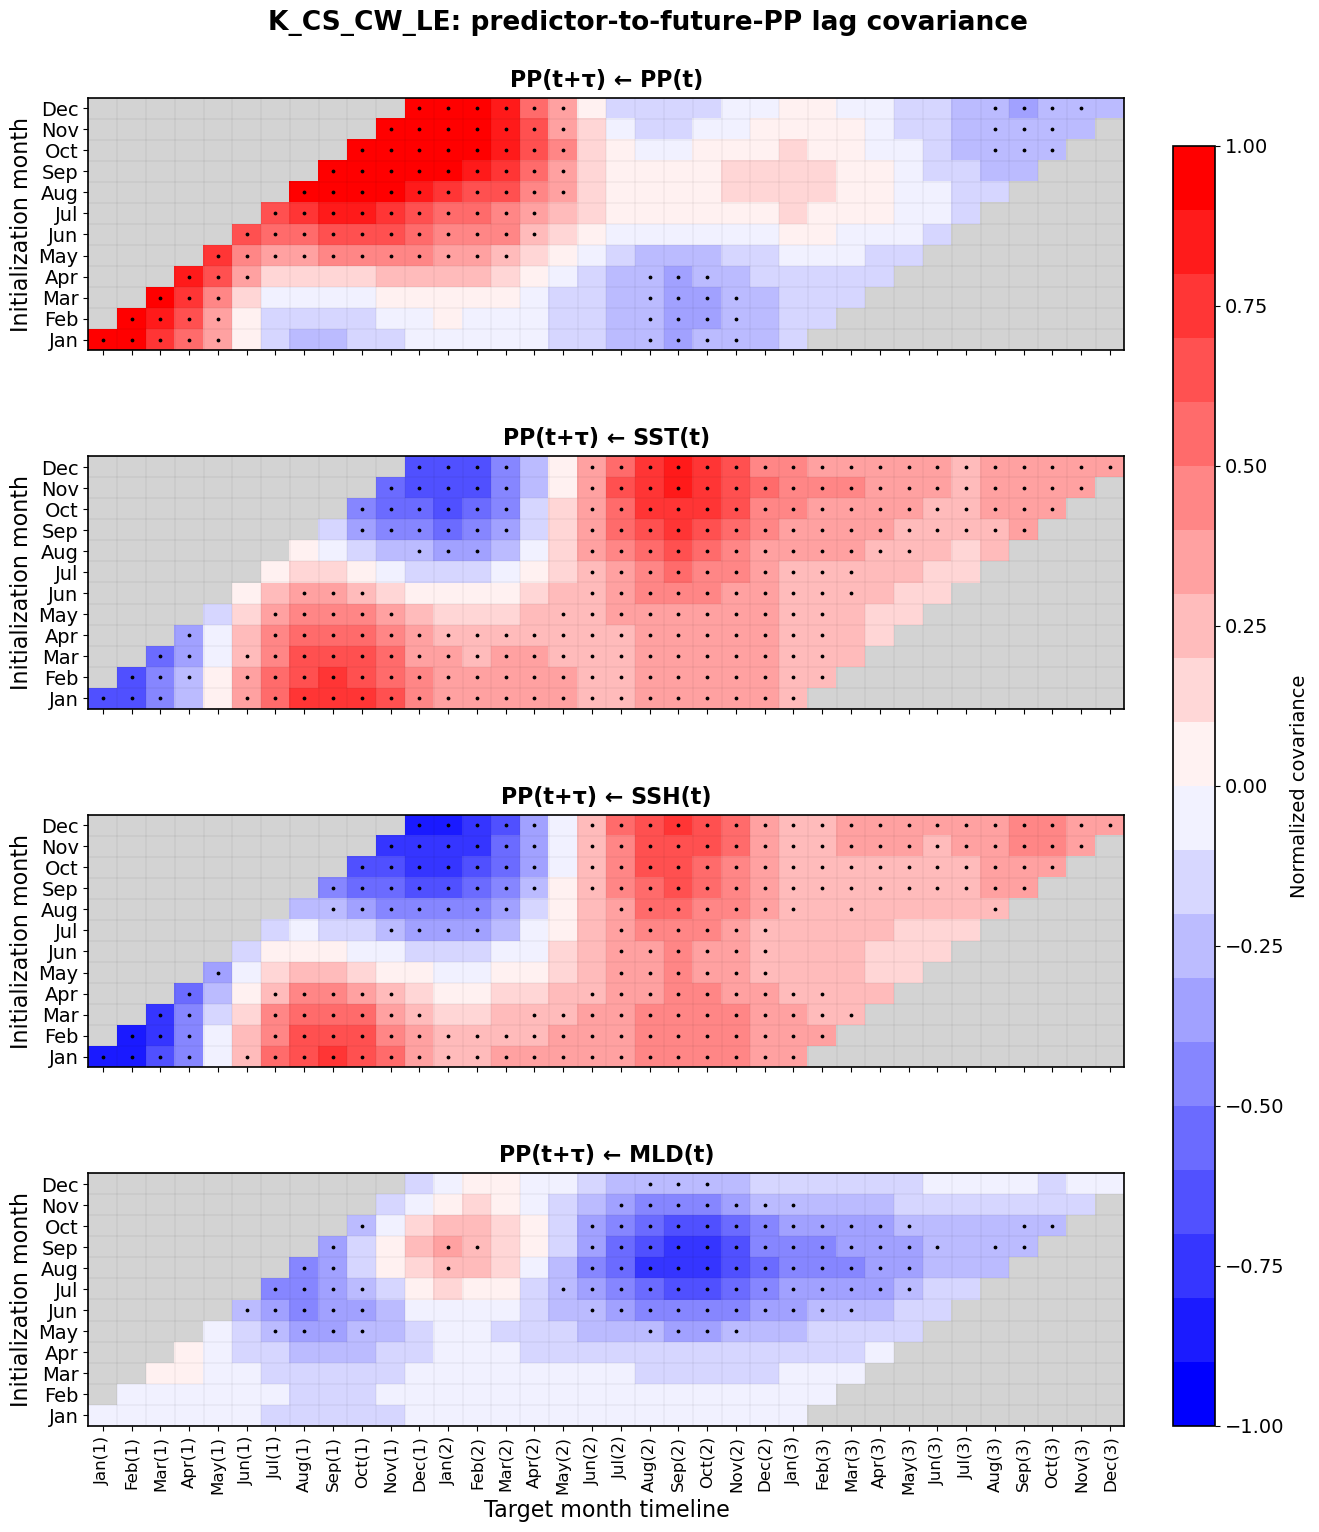

In [15]:
# example: LE-CS-CW

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import t


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 14,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

# Dataset
ds = ds_k

# Variable to plot
k_var = "K_CS_CW_LE"

# State order in the NetCDF file
state_names = ["PP", "SST", "SSH", "MLD"]

# Future target state
target_name = "PP"
target_idx = 0

# Present predictors
predictor_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12

# Use all available leads unless you want to limit it
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]
lead_dim = None

for dim in lead_dim_candidates:
    if dim in ds[k_var].dims:
        lead_dim = dim
        break

if lead_dim is None:
    raise ValueError(f"No lead dimension found in {ds[k_var].dims}")

max_lag = ds[k_var].sizes[lead_dim] - 1

# Optional significance threshold.
# If you already have rcrit, set it here.
# If you do not want significance dots, set rcrit = None.
# significance (same as MATLAB)
N = 64
nu = N - 2
tcrit = t.ppf(1 - 0.05/2, nu)
rcrit = np.sqrt(tcrit**2 / (tcrit**2 + nu))


# ============================================================
# 2. Extract K_CS_CW_LE as month x lead matrices
# ============================================================

K = ds[k_var]

# Detect ensemble dimension
ens_dim = None
for dim in ["ens", "ens_LE", "ensemble", "member"]:
    if dim in K.dims:
        ens_dim = dim
        break

if ens_dim is not None:
    K_mean = K.mean(dim=ens_dim)
else:
    K_mean = K

# Make sure dims are available
required_dims = ["state_i", "state_j", "month", lead_dim]
for dim in required_dims:
    if dim not in K_mean.dims:
        raise ValueError(f"{dim} not found in {k_var}. dims={K_mean.dims}")

# Dictionary: predictor name -> month x lead matrix
corr_maps_LIM = {}

for pname, pidx in predictor_indices.items():

    C = (
        K_mean
        .isel(state_i=target_idx, state_j=pidx)
        .transpose("month", lead_dim)
        .values
    )

    corr_maps_LIM[pname] = C


# ============================================================
# 3. ORAS-style target-month alignment
# ============================================================

def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """

    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


calendar = month_names
labels = []

year = 1
for i in range(max_lag + 12):
    mo = i % 12
    if i > 0 and mo == 0:
        year += 1
    labels.append(f"{calendar[mo]}({year})")


# ============================================================
# 4. MATLAB-style blue-white-red colormap
# ============================================================

nColors = 20
base_colors = np.array([
    [0, 0, 1],   # blue
    [1, 1, 1],   # white
    [1, 0, 0],   # red
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")



# ============================================================
# 5. Plot - cleaner layout
# ============================================================

# Set rcrit = None if you do not want dots
# rcrit = None
# rcrit = 0.25

n_panel = len(corr_maps_LIM)

fig, axes = plt.subplots(
    n_panel, 1,
    figsize=(14, 4 * n_panel),
    sharex=True,
)

if n_panel == 1:
    axes = [axes]

# Manual layout control
fig.subplots_adjust(
    left=0.10,
    right=0.84,
    bottom=0.10,
    top=0.93,
    hspace=0.42,
)

im = None

for ax, (pname, C) in zip(axes, corr_maps_LIM.items()):

    skill = shifted_target_matrix(C, max_lag)
    masked = np.ma.masked_invalid(skill)

    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-1,
        vmax=1,
        interpolation="none",
    )

    # Optional significance dots
    if rcrit is not None:
        sig = (np.abs(skill) >= rcrit) & np.isfinite(skill)
        iy, ix = np.where(sig)

        ax.scatter(
            ix,
            iy,
            s=12,
            c="k",
            marker=".",
        )    
    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_names)
    ax.set_ylabel("Initialization month")

    ax.set_title(
        f"{target_name}(t+τ) ← {pname}(t)",
        pad=8,
        fontsize=16,
        fontweight="bold",
    )

    # Grid lines between months and target months
    ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(
        which="minor",
        color="k",
        linestyle="-",
        linewidth=0.25,
        alpha=0.20,
    )
    ax.tick_params(which="minor", bottom=False, left=False)

axes[-1].set_xticks(np.arange(len(labels)))
axes[-1].set_xticklabels(labels, rotation=90)
axes[-1].set_xlabel("Target month timeline")

# Dedicated colorbar axis
cax = fig.add_axes([0.875, 0.1, 0.03, 0.8])

cbar = fig.colorbar(
    im,
    cax=cax,
    extend="neither",
)

cbar.set_label("Normalized covariance", fontsize=14)

fig.suptitle(
    f"{k_var}: predictor-to-future-{target_name} lag covariance",
    fontsize=19,
    fontweight="bold",
    y=0.985,
)

plt.show()

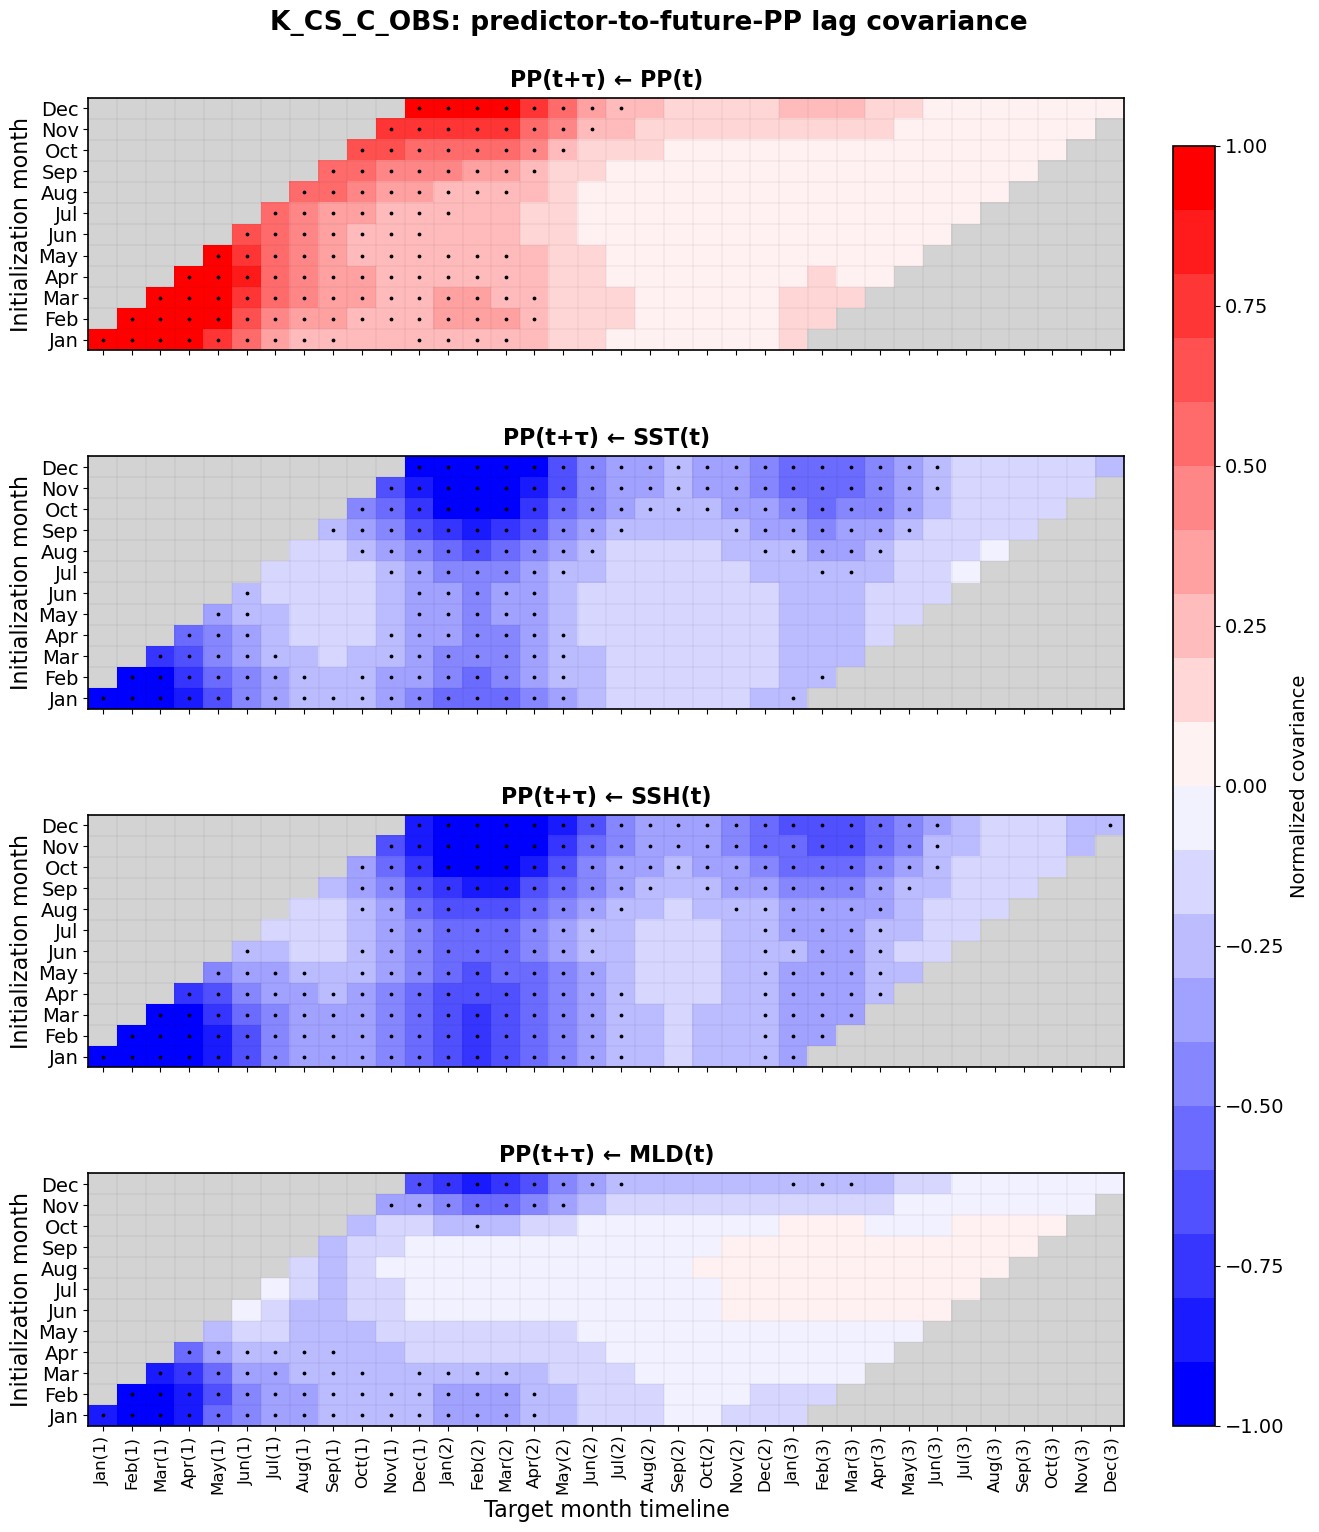

In [23]:
# example: LE-CS-White

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import t


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 14,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

# Dataset
ds = ds_k

# Variable to plot
# k_var = "K_CS_W_LE"
# k_var = "K_CS_C_LE"
# k_var = "K_CS_OBS_LE"
# k_var = "K_CS_OBS_OBS"
# k_var = "K_CS_W_OBS"
k_var = "K_CS_C_OBS"

# State order in the NetCDF file
state_names = ["PP", "SST", "SSH", "MLD"]

# Future target state
target_name = "PP"
target_idx = 0

# Present predictors
predictor_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12

# Use all available leads unless you want to limit it
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]
lead_dim = None

for dim in lead_dim_candidates:
    if dim in ds[k_var].dims:
        lead_dim = dim
        break

if lead_dim is None:
    raise ValueError(f"No lead dimension found in {ds[k_var].dims}")

max_lag = ds[k_var].sizes[lead_dim] - 1

# Optional significance threshold.
# If you already have rcrit, set it here.
# If you do not want significance dots, set rcrit = None.
# significance (same as MATLAB)
N = 64
nu = N - 2
tcrit = t.ppf(1 - 0.05/2, nu)
rcrit = np.sqrt(tcrit**2 / (tcrit**2 + nu))


# ============================================================
# 2. Extract K_CS_CW_LE as month x lead matrices
# ============================================================

K = ds[k_var]

# Detect ensemble dimension
ens_dim = None
for dim in ["ens", "ens_LE", "ensemble", "member"]:
    if dim in K.dims:
        ens_dim = dim
        break

if ens_dim is not None:
    K_mean = K.mean(dim=ens_dim)
else:
    K_mean = K

# Make sure dims are available
required_dims = ["state_i", "state_j", "month", lead_dim]
for dim in required_dims:
    if dim not in K_mean.dims:
        raise ValueError(f"{dim} not found in {k_var}. dims={K_mean.dims}")

# Dictionary: predictor name -> month x lead matrix
corr_maps_LIM = {}

for pname, pidx in predictor_indices.items():

    C = (
        K_mean
        .isel(state_i=target_idx, state_j=pidx)
        .transpose("month", lead_dim)
        .values
    )

    corr_maps_LIM[pname] = C


# ============================================================
# 3. ORAS-style target-month alignment
# ============================================================

def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """

    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


calendar = month_names
labels = []

year = 1
for i in range(max_lag + 12):
    mo = i % 12
    if i > 0 and mo == 0:
        year += 1
    labels.append(f"{calendar[mo]}({year})")


# ============================================================
# 4. MATLAB-style blue-white-red colormap
# ============================================================

nColors = 20
base_colors = np.array([
    [0, 0, 1],   # blue
    [1, 1, 1],   # white
    [1, 0, 0],   # red
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")



# ============================================================
# 5. Plot - cleaner layout
# ============================================================

# Set rcrit = None if you do not want dots
# rcrit = None
# rcrit = 0.25

n_panel = len(corr_maps_LIM)

fig, axes = plt.subplots(
    n_panel, 1,
    figsize=(14, 4 * n_panel),
    sharex=True,
)

if n_panel == 1:
    axes = [axes]

# Manual layout control
fig.subplots_adjust(
    left=0.10,
    right=0.84,
    bottom=0.10,
    top=0.93,
    hspace=0.42,
)

im = None

for ax, (pname, C) in zip(axes, corr_maps_LIM.items()):

    skill = shifted_target_matrix(C, max_lag)
    masked = np.ma.masked_invalid(skill)

    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-1,
        vmax=1,
        interpolation="none",
    )

    # Optional significance dots
    if rcrit is not None:
        sig = (np.abs(skill) >= rcrit) & np.isfinite(skill)
        iy, ix = np.where(sig)

        ax.scatter(
            ix,
            iy,
            s=12,
            c="k",
            marker=".",
        )    
    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_names)
    ax.set_ylabel("Initialization month")

    ax.set_title(
        f"{target_name}(t+τ) ← {pname}(t)",
        pad=8,
        fontsize=16,
        fontweight="bold",
    )

    # Grid lines between months and target months
    ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(
        which="minor",
        color="k",
        linestyle="-",
        linewidth=0.25,
        alpha=0.20,
    )
    ax.tick_params(which="minor", bottom=False, left=False)

axes[-1].set_xticks(np.arange(len(labels)))
axes[-1].set_xticklabels(labels, rotation=90)
axes[-1].set_xlabel("Target month timeline")

# Dedicated colorbar axis
cax = fig.add_axes([0.875, 0.1, 0.03, 0.8])

cbar = fig.colorbar(
    im,
    cax=cax,
    extend="neither",
)

cbar.set_label("Normalized covariance", fontsize=14)

fig.suptitle(
    f"{k_var}: predictor-to-future-{target_name} lag covariance",
    fontsize=19,
    fontweight="bold",
    y=0.985,
)

plt.show()

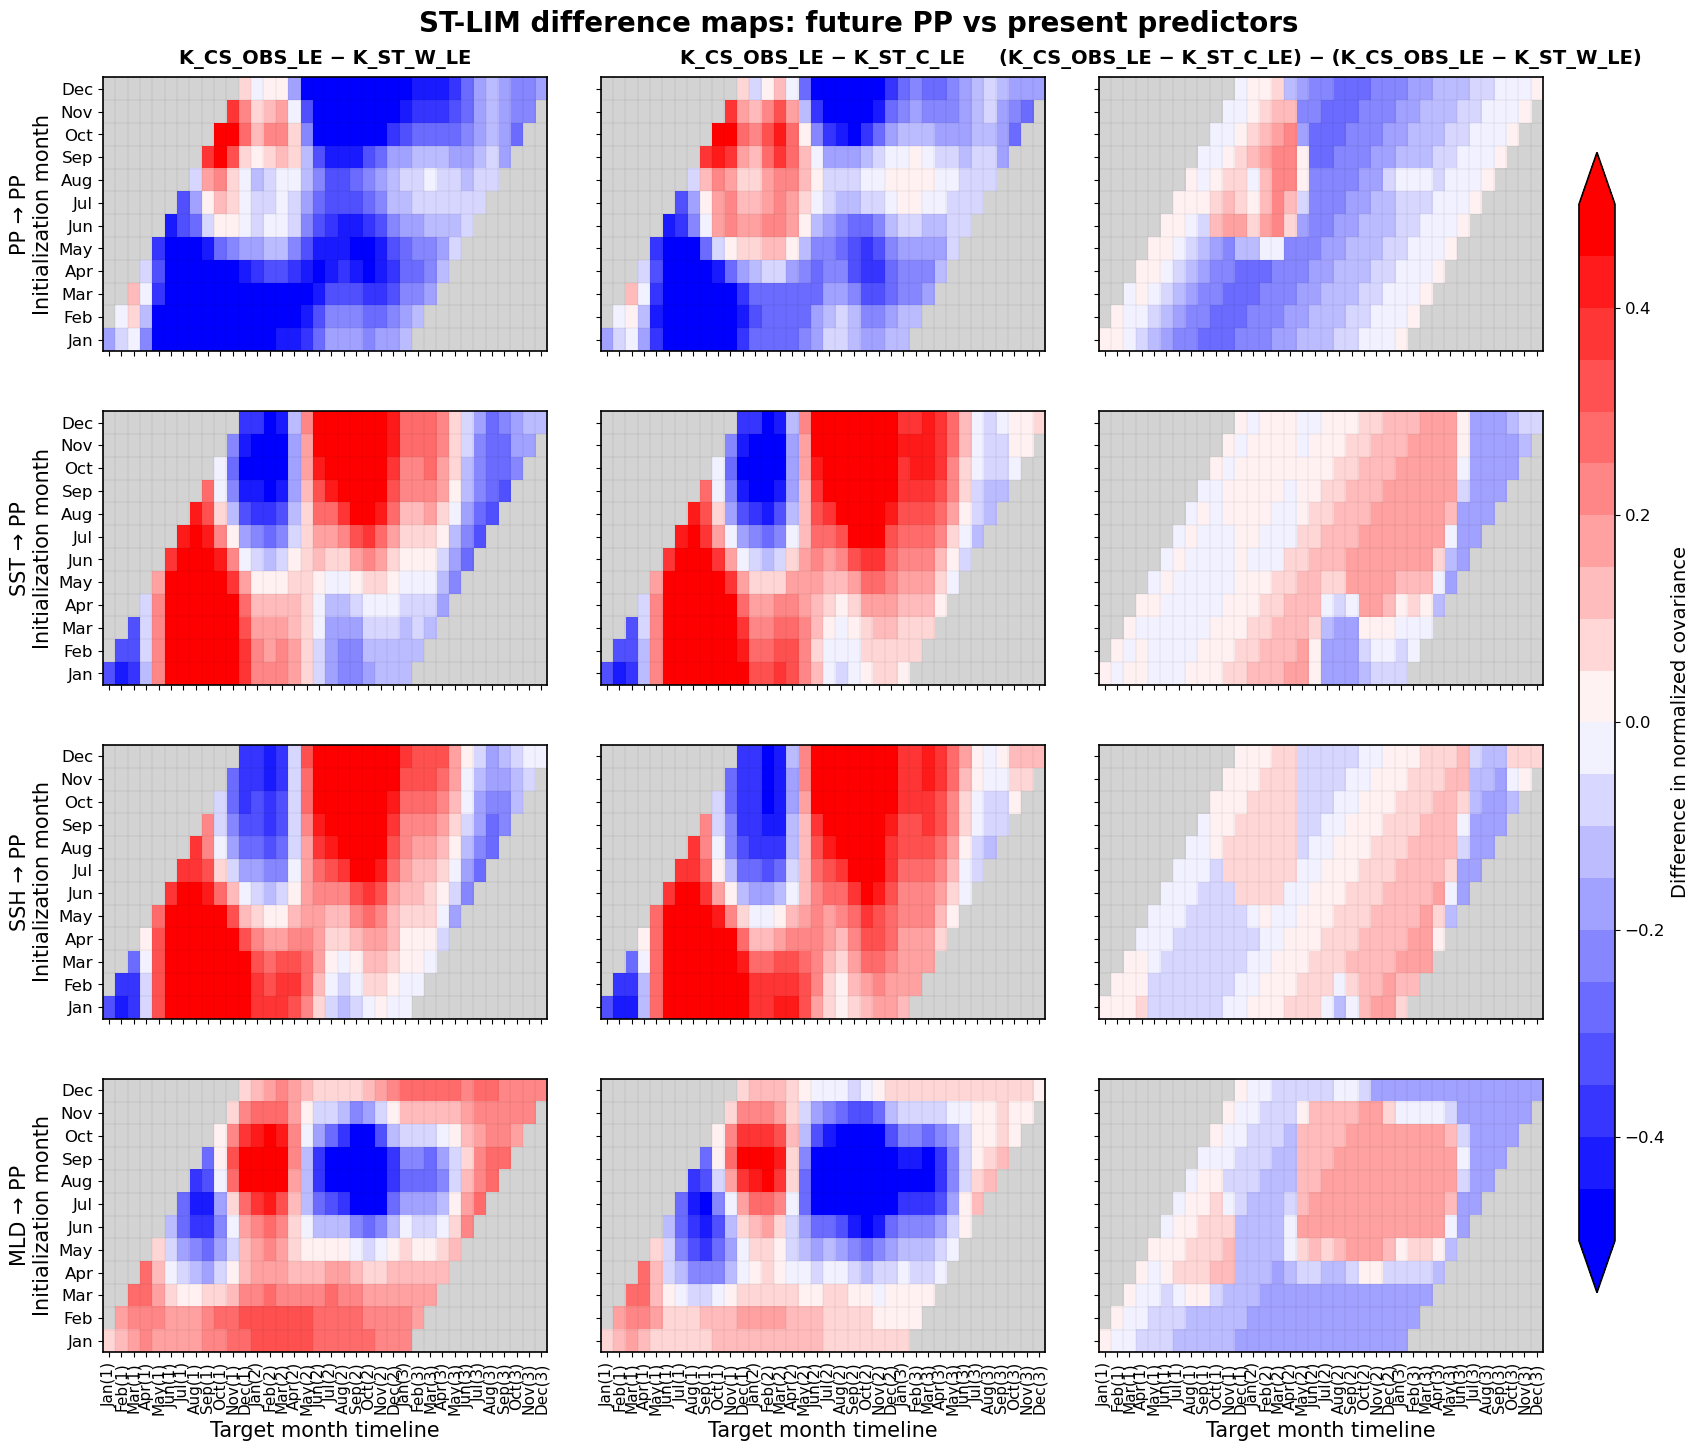

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

target_name = "PP"
target_idx = 0

predictor_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

predictor_names = list(predictor_indices.keys())

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def get_month_lead_matrix(k_var, target_idx, predictor_idx):
    """
    Extract K[target, predictor] as [month, lead].

    If the variable has no 'month' dimension (typical ST case),
    repeat the same [lead] vector for all 12 initialization months.
    """

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        C = da_sel.transpose("month", lead_dim).values
    else:
        C_lead = da_sel.transpose(lead_dim).values
        C = np.tile(C_lead[None, :], (n_month, 1))

    return C


def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """
    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


def make_target_month_labels(max_lag):
    labels = []
    year = 1

    for i in range(max_lag + 12):
        mo = i % 12
        if i > 0 and mo == 0:
            year += 1
        labels.append(f"{month_names[mo]}({year})")

    return labels


# ============================================================
# 3. Load ST matrices
# ============================================================

k_obs = "K_CS_OBS_LE"
k_w   = "K_ST_W_LE"
k_c   = "K_ST_C_LE"

C_obs_all = {}
C_w_all   = {}
C_c_all   = {}

for pname, pidx in predictor_indices.items():
    C_obs_all[pname] = get_month_lead_matrix(k_obs, target_idx, pidx)
    C_w_all[pname]   = get_month_lead_matrix(k_w,   target_idx, pidx)
    C_c_all[pname]   = get_month_lead_matrix(k_c,   target_idx, pidx)

# Use common lead length across all predictors and variables
n_lead = min(
    *[C_obs_all[p].shape[1] for p in predictor_names],
    *[C_w_all[p].shape[1]   for p in predictor_names],
    *[C_c_all[p].shape[1]   for p in predictor_names],
)
max_lag = n_lead - 1

for pname in predictor_names:
    C_obs_all[pname] = C_obs_all[pname][:, :n_lead]
    C_w_all[pname]   = C_w_all[pname][:, :n_lead]
    C_c_all[pname]   = C_c_all[pname][:, :n_lead]

labels = make_target_month_labels(max_lag)


# ============================================================
# 4. Build panel matrices
# ============================================================

panel_titles = [
    "K_CS_OBS_LE − K_ST_W_LE",
    "K_CS_OBS_LE − K_ST_C_LE",
    "(K_CS_OBS_LE − K_ST_C_LE) − (K_CS_OBS_LE − K_ST_W_LE)",
]

panel_data = {}

for pname in predictor_names:
    diff1 = C_obs_all[pname] - C_w_all[pname]
    diff2 = C_obs_all[pname] - C_c_all[pname]
    diff3 = np.abs(diff2) - np.abs(diff1)   # Equivalent to K_ST_W_LE - K_ST_C_LE

    panel_data[pname] = [diff1, diff2, diff3]


# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20
base_colors = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 0],
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Common color range
# ============================================================

all_values = []
for pname in predictor_names:
    for arr in panel_data[pname]:
        all_values.append(arr[np.isfinite(arr)].ravel())

all_values = np.concatenate(all_values)
vlim = np.nanmax(np.abs(all_values))
vlim = np.ceil(vlim * 20) / 20
vlim = 0.5
if vlim == 0:
    vlim = 0.1


# ============================================================
# 7. Plot: 4 rows x 3 columns
# ============================================================

n_row = len(predictor_names)
n_col = 3

fig, axes = plt.subplots(
    n_row, n_col,
    figsize=(18, 15),
    sharex=True,
    sharey=True,
)

fig.subplots_adjust(
    left=0.08,
    right=0.88,
    bottom=0.08,
    top=0.93,
    wspace=0.12,
    hspace=0.22,
)

im = None

for irow, pname in enumerate(predictor_names):
    for icol in range(n_col):
        ax = axes[irow, icol]

        Cdiff = panel_data[pname][icol]
        skill = shifted_target_matrix(Cdiff, max_lag)
        masked = np.ma.masked_invalid(skill)

        im = ax.imshow(
            masked,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=-vlim,
            vmax=vlim,
            interpolation="none",
        )

        # Column titles
        if irow == 0:
            ax.set_title(panel_titles[icol], fontsize=14, fontweight="bold", pad=10)

        # Row labels
        if icol == 0:
            ax.set_ylabel(f"{pname} → {target_name}\nInitialization month")

        # Ticks
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(month_names)

        # Grid lines
        ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
        ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
        ax.grid(
            which="minor",
            color="k",
            linestyle="-",
            linewidth=0.25,
            alpha=0.20,
        )
        ax.tick_params(which="minor", bottom=False, left=False)

        # Bottom x labels only
        if irow == n_row - 1:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=90)
            ax.set_xlabel("Target month timeline")
        else:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels([])

# Colorbar
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
cbar = fig.colorbar(im, cax=cax, extend="both")
cbar.set_label("Difference in normalized covariance", fontsize=14)

fig.suptitle(
    f"ST-LIM difference maps: future {target_name} vs present predictors",
    fontsize=20,
    fontweight="bold",
    y=0.975,
)

plt.show()

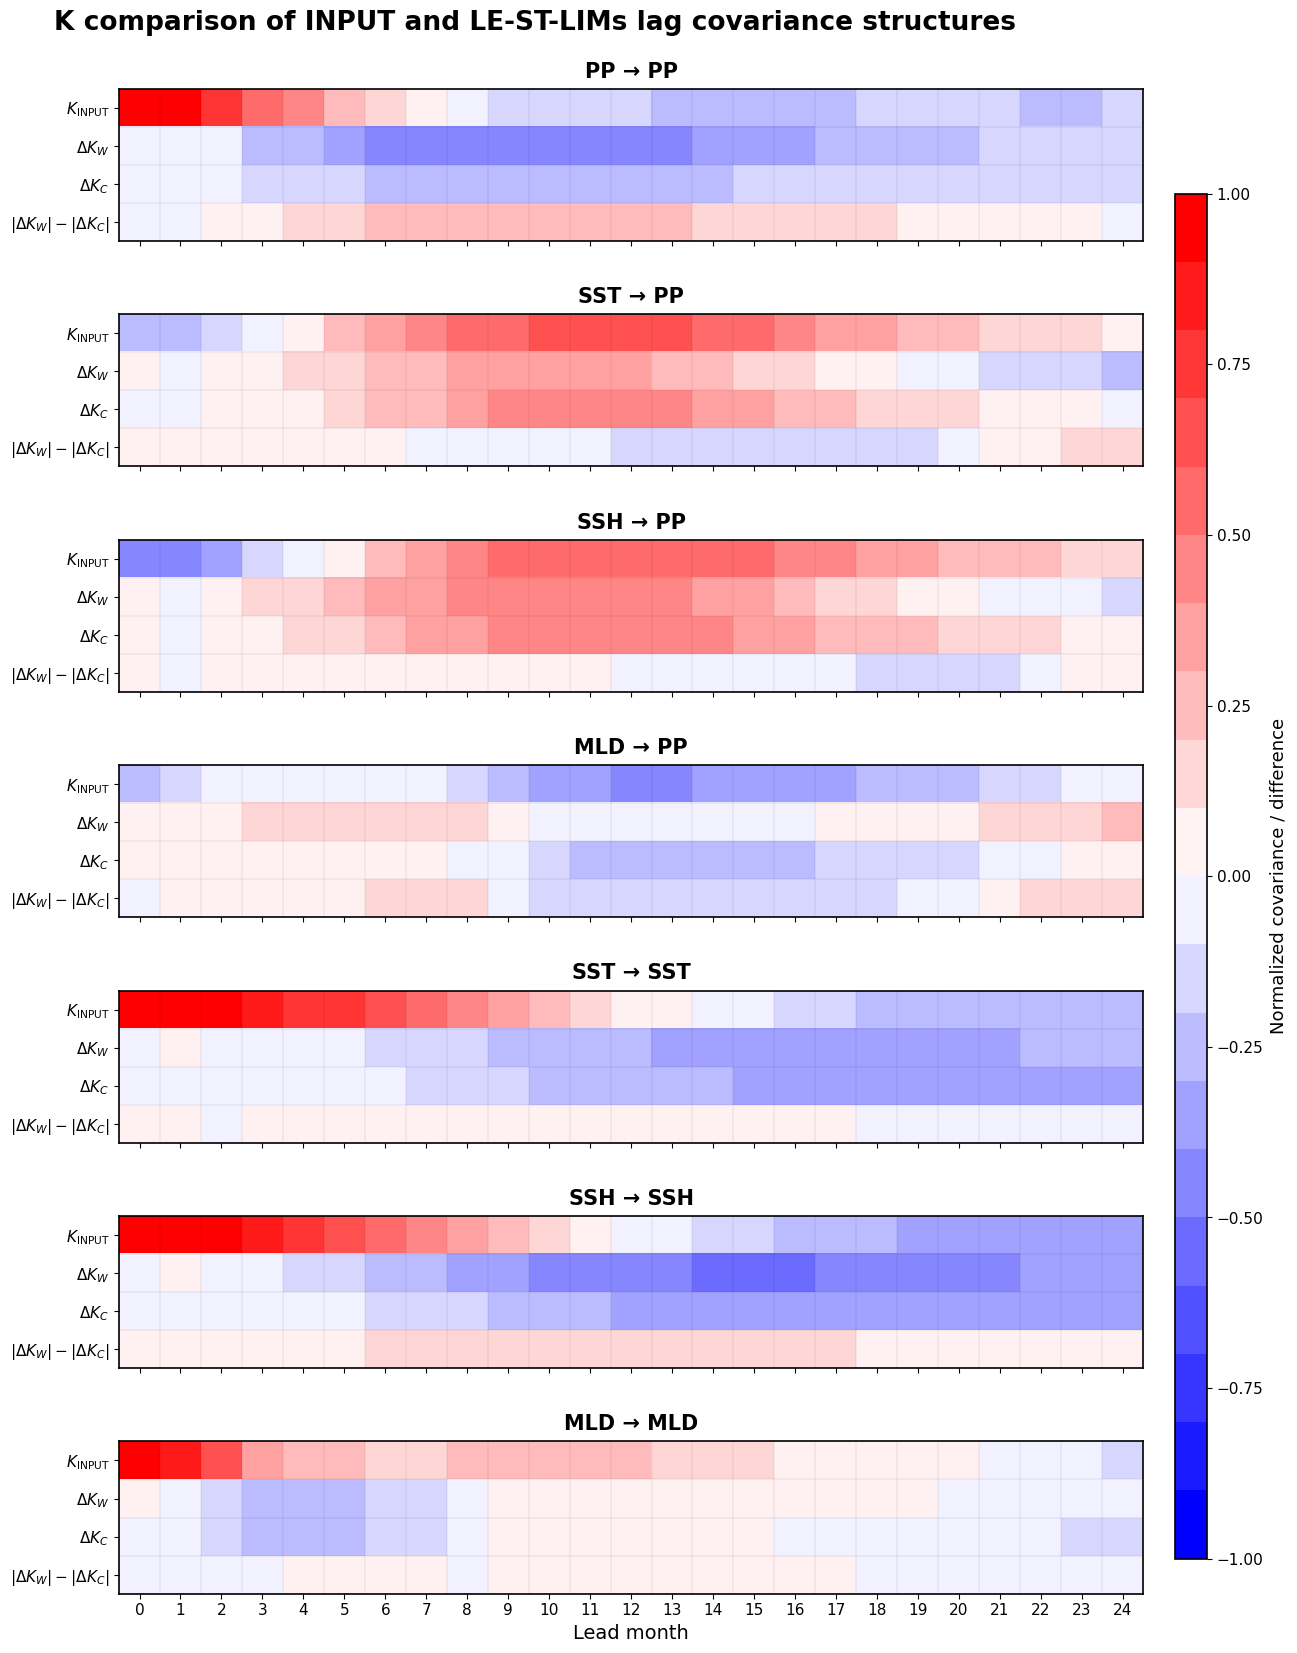

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

# Rows to plot: predictor -> target
plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),
    ("MLD", "MLD"),
]

lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def get_lead_vector(k_var, target_idx, predictor_idx, reduce_month="mean"):
    """
    Extract K[target, predictor] as [lead].

    If 'month' exists, reduce it to a single lead vector.
    Default behavior: monthly mean over 'month'.
    """

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        if reduce_month == "mean":
            da_sel = da_sel.mean(dim="month")
        elif reduce_month == "median":
            da_sel = da_sel.median(dim="month")
        else:
            raise ValueError(f"Unsupported reduce_month option: {reduce_month}")

    vec = da_sel.transpose(lead_dim).values

    return vec


# ============================================================
# 3. Load vectors for all target-predictor pairs
# ============================================================

k_input = "K_ST_OBS_LE"
k_w     = "K_ST_W_LE"
k_c     = "K_ST_C_LE"

input_all = {}
w_all     = {}
c_all     = {}

for predictor_name, target_name in plot_pairs:

    predictor_idx = state_indices[predictor_name]
    target_idx    = state_indices[target_name]

    pair_key = f"{predictor_name}->{target_name}"

    input_all[pair_key] = get_lead_vector(
        k_input, target_idx, predictor_idx, reduce_month="mean"
    )

    w_all[pair_key] = get_lead_vector(
        k_w, target_idx, predictor_idx, reduce_month="mean"
    )

    c_all[pair_key] = get_lead_vector(
        k_c, target_idx, predictor_idx, reduce_month="mean"
    )


# Use common lead length across all pairs and variables
pair_keys = [f"{p}->{t}" for p, t in plot_pairs]

n_lead = min(
    *[input_all[key].shape[0] for key in pair_keys],
    *[w_all[key].shape[0]     for key in pair_keys],
    *[c_all[key].shape[0]     for key in pair_keys],
)

for key in pair_keys:
    input_all[key] = input_all[key][:n_lead]
    w_all[key]     = w_all[key][:n_lead]
    c_all[key]     = c_all[key][:n_lead]

lead_vals = np.arange(n_lead)


# ============================================================
# 4. Build panel matrices
# ============================================================

panel_data = {}

for key in pair_keys:

    input_k = input_all[key]

    diff_w = input_all[key] - w_all[key]
    diff_c = input_all[key] - c_all[key]

    # Positive means ST-Colored is closer to INPUT than ST-White
    diff_abs = np.abs(diff_w) - np.abs(diff_c)

    # origin="lower" 이므로,
    # vstack의 마지막 행이 그림에서 맨 위에 표시됨.
    panel_data[key] = np.vstack([
        diff_abs,   # bottom row
        diff_c,
        diff_w,
        input_k,    # top row
    ])

row_labels_inside_panel = [
    r"$|\Delta K_W| - |\Delta K_C|$",
    r"$\Delta K_C$",
    r"$\Delta K_W$",
    r"$K_{\mathrm{INPUT}}$",
]



# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],   # blue
    [1, 1, 1],   # white
    [1, 0, 0],   # red
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Common color range
# ============================================================

all_values = np.concatenate([
    panel_data[key][np.isfinite(panel_data[key])].ravel()
    for key in pair_keys
])

vlim = np.nanmax(np.abs(all_values))
vlim = np.ceil(vlim * 20) / 20

# Manual override
vlim = 1.0

if vlim == 0:
    vlim = 0.1


# ============================================================
# 7. Plot: one target-predictor pair per panel
# ============================================================

n_panel = len(pair_keys)

fig, axes = plt.subplots(
    n_panel, 1,
    figsize=(16, 17.5),   # 4 rows per panel, so slightly taller
    sharex=True,
)

if n_panel == 1:
    axes = [axes]

fig.subplots_adjust(
    left=0.24,
    right=0.88,
    bottom=0.08,
    top=0.94,
    hspace=0.48,
)

im = None

for i, ((predictor_name, target_name), key) in enumerate(zip(plot_pairs, pair_keys)):

    ax = axes[i]
    M = panel_data[key]   # shape = (4, n_lead)

    im = ax.imshow(
        M,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-vlim,
        vmax=vlim,
        interpolation="none",
    )

    ax.set_yticks(np.arange(4))
    ax.set_yticklabels(row_labels_inside_panel)

    ax.set_title(
        f"{predictor_name} → {target_name}",
        fontsize=15,
        fontweight="bold",
        pad=8,
    )

    # Grid
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, n_lead, 1), minor=True)

    ax.grid(
        which="minor",
        color="k",
        linestyle="-",
        linewidth=0.25,
        alpha=0.25,
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    if i == n_panel - 1:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels(lead_vals)
        ax.set_xlabel("Lead month")
    else:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels([])


# Colorbar
cax = fig.add_axes([0.90, 0.10, 0.02, 0.78])

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label("Normalized covariance / difference", fontsize=13)

fig.suptitle(
    "K comparison of INPUT and LE-ST-LIMs lag covariance structures",
    fontsize=19,
    fontweight="bold",
    y=0.985,
)

plt.show()

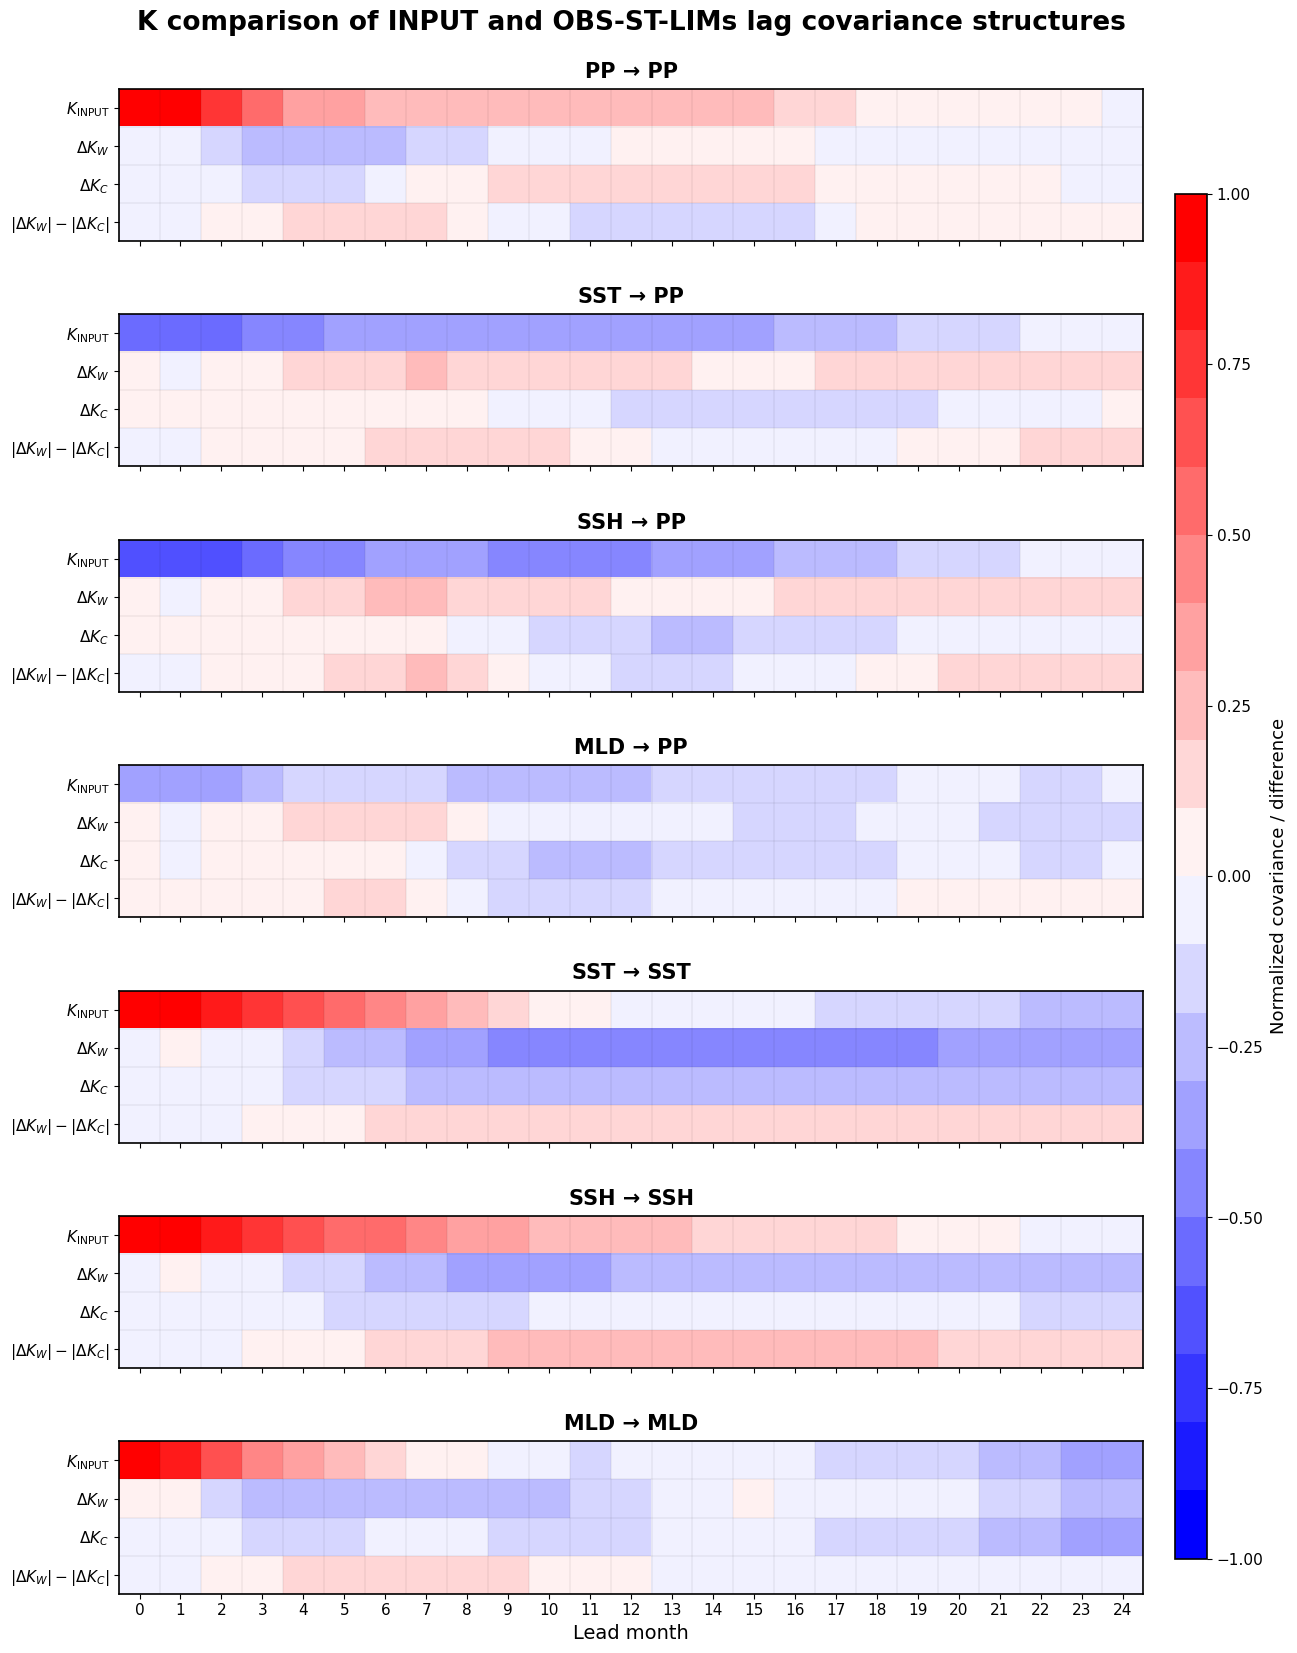

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

# Rows to plot: predictor -> target
plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),
    ("MLD", "MLD"),
]

lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def get_lead_vector(k_var, target_idx, predictor_idx, reduce_month="mean"):
    """
    Extract K[target, predictor] as [lead].

    If 'month' exists, reduce it to a single lead vector.
    Default behavior: monthly mean over 'month'.
    """

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        if reduce_month == "mean":
            da_sel = da_sel.mean(dim="month")
        elif reduce_month == "median":
            da_sel = da_sel.median(dim="month")
        else:
            raise ValueError(f"Unsupported reduce_month option: {reduce_month}")

    vec = da_sel.transpose(lead_dim).values

    return vec


# ============================================================
# 3. Load vectors for all target-predictor pairs
# ============================================================

k_input = "K_ST_OBS_OBS"
k_w     = "K_ST_W_OBS"
k_c     = "K_ST_C_OBS"

input_all = {}
w_all     = {}
c_all     = {}

for predictor_name, target_name in plot_pairs:

    predictor_idx = state_indices[predictor_name]
    target_idx    = state_indices[target_name]

    pair_key = f"{predictor_name}->{target_name}"

    input_all[pair_key] = get_lead_vector(
        k_input, target_idx, predictor_idx, reduce_month="mean"
    )

    w_all[pair_key] = get_lead_vector(
        k_w, target_idx, predictor_idx, reduce_month="mean"
    )

    c_all[pair_key] = get_lead_vector(
        k_c, target_idx, predictor_idx, reduce_month="mean"
    )


# Use common lead length across all pairs and variables
pair_keys = [f"{p}->{t}" for p, t in plot_pairs]

n_lead = min(
    *[input_all[key].shape[0] for key in pair_keys],
    *[w_all[key].shape[0]     for key in pair_keys],
    *[c_all[key].shape[0]     for key in pair_keys],
)

for key in pair_keys:
    input_all[key] = input_all[key][:n_lead]
    w_all[key]     = w_all[key][:n_lead]
    c_all[key]     = c_all[key][:n_lead]

lead_vals = np.arange(n_lead)


# ============================================================
# 4. Build panel matrices
# ============================================================

panel_data = {}

for key in pair_keys:

    input_k = input_all[key]

    diff_w = input_all[key] - w_all[key]
    diff_c = input_all[key] - c_all[key]

    # Positive means ST-Colored is closer to INPUT than ST-White
    diff_abs = np.abs(diff_w) - np.abs(diff_c)

    # origin="lower" 이므로,
    # vstack의 마지막 행이 그림에서 맨 위에 표시됨.
    panel_data[key] = np.vstack([
        diff_abs,   # bottom row
        diff_c,
        diff_w,
        input_k,    # top row
    ])

row_labels_inside_panel = [
    r"$|\Delta K_W| - |\Delta K_C|$",
    r"$\Delta K_C$",
    r"$\Delta K_W$",
    r"$K_{\mathrm{INPUT}}$",
]



# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],   # blue
    [1, 1, 1],   # white
    [1, 0, 0],   # red
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Common color range
# ============================================================

all_values = np.concatenate([
    panel_data[key][np.isfinite(panel_data[key])].ravel()
    for key in pair_keys
])

vlim = np.nanmax(np.abs(all_values))
vlim = np.ceil(vlim * 20) / 20

# Manual override
vlim = 1.0

if vlim == 0:
    vlim = 0.1


# ============================================================
# 7. Plot: one target-predictor pair per panel
# ============================================================

n_panel = len(pair_keys)

fig, axes = plt.subplots(
    n_panel, 1,
    figsize=(16, 17.5),   # 4 rows per panel, so slightly taller
    sharex=True,
)

if n_panel == 1:
    axes = [axes]

fig.subplots_adjust(
    left=0.24,
    right=0.88,
    bottom=0.08,
    top=0.94,
    hspace=0.48,
)

im = None

for i, ((predictor_name, target_name), key) in enumerate(zip(plot_pairs, pair_keys)):

    ax = axes[i]
    M = panel_data[key]   # shape = (4, n_lead)

    im = ax.imshow(
        M,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-vlim,
        vmax=vlim,
        interpolation="none",
    )

    ax.set_yticks(np.arange(4))
    ax.set_yticklabels(row_labels_inside_panel)

    ax.set_title(
        f"{predictor_name} → {target_name}",
        fontsize=15,
        fontweight="bold",
        pad=8,
    )

    # Grid
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, n_lead, 1), minor=True)

    ax.grid(
        which="minor",
        color="k",
        linestyle="-",
        linewidth=0.25,
        alpha=0.25,
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    if i == n_panel - 1:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels(lead_vals)
        ax.set_xlabel("Lead month")
    else:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels([])


# Colorbar
cax = fig.add_axes([0.90, 0.10, 0.02, 0.78])

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label("Normalized covariance / difference", fontsize=13)

fig.suptitle(
    "K comparison of INPUT and OBS-ST-LIMs lag covariance structures",
    fontsize=19,
    fontweight="bold",
    x= 0.56, y=0.985,
)

plt.show()

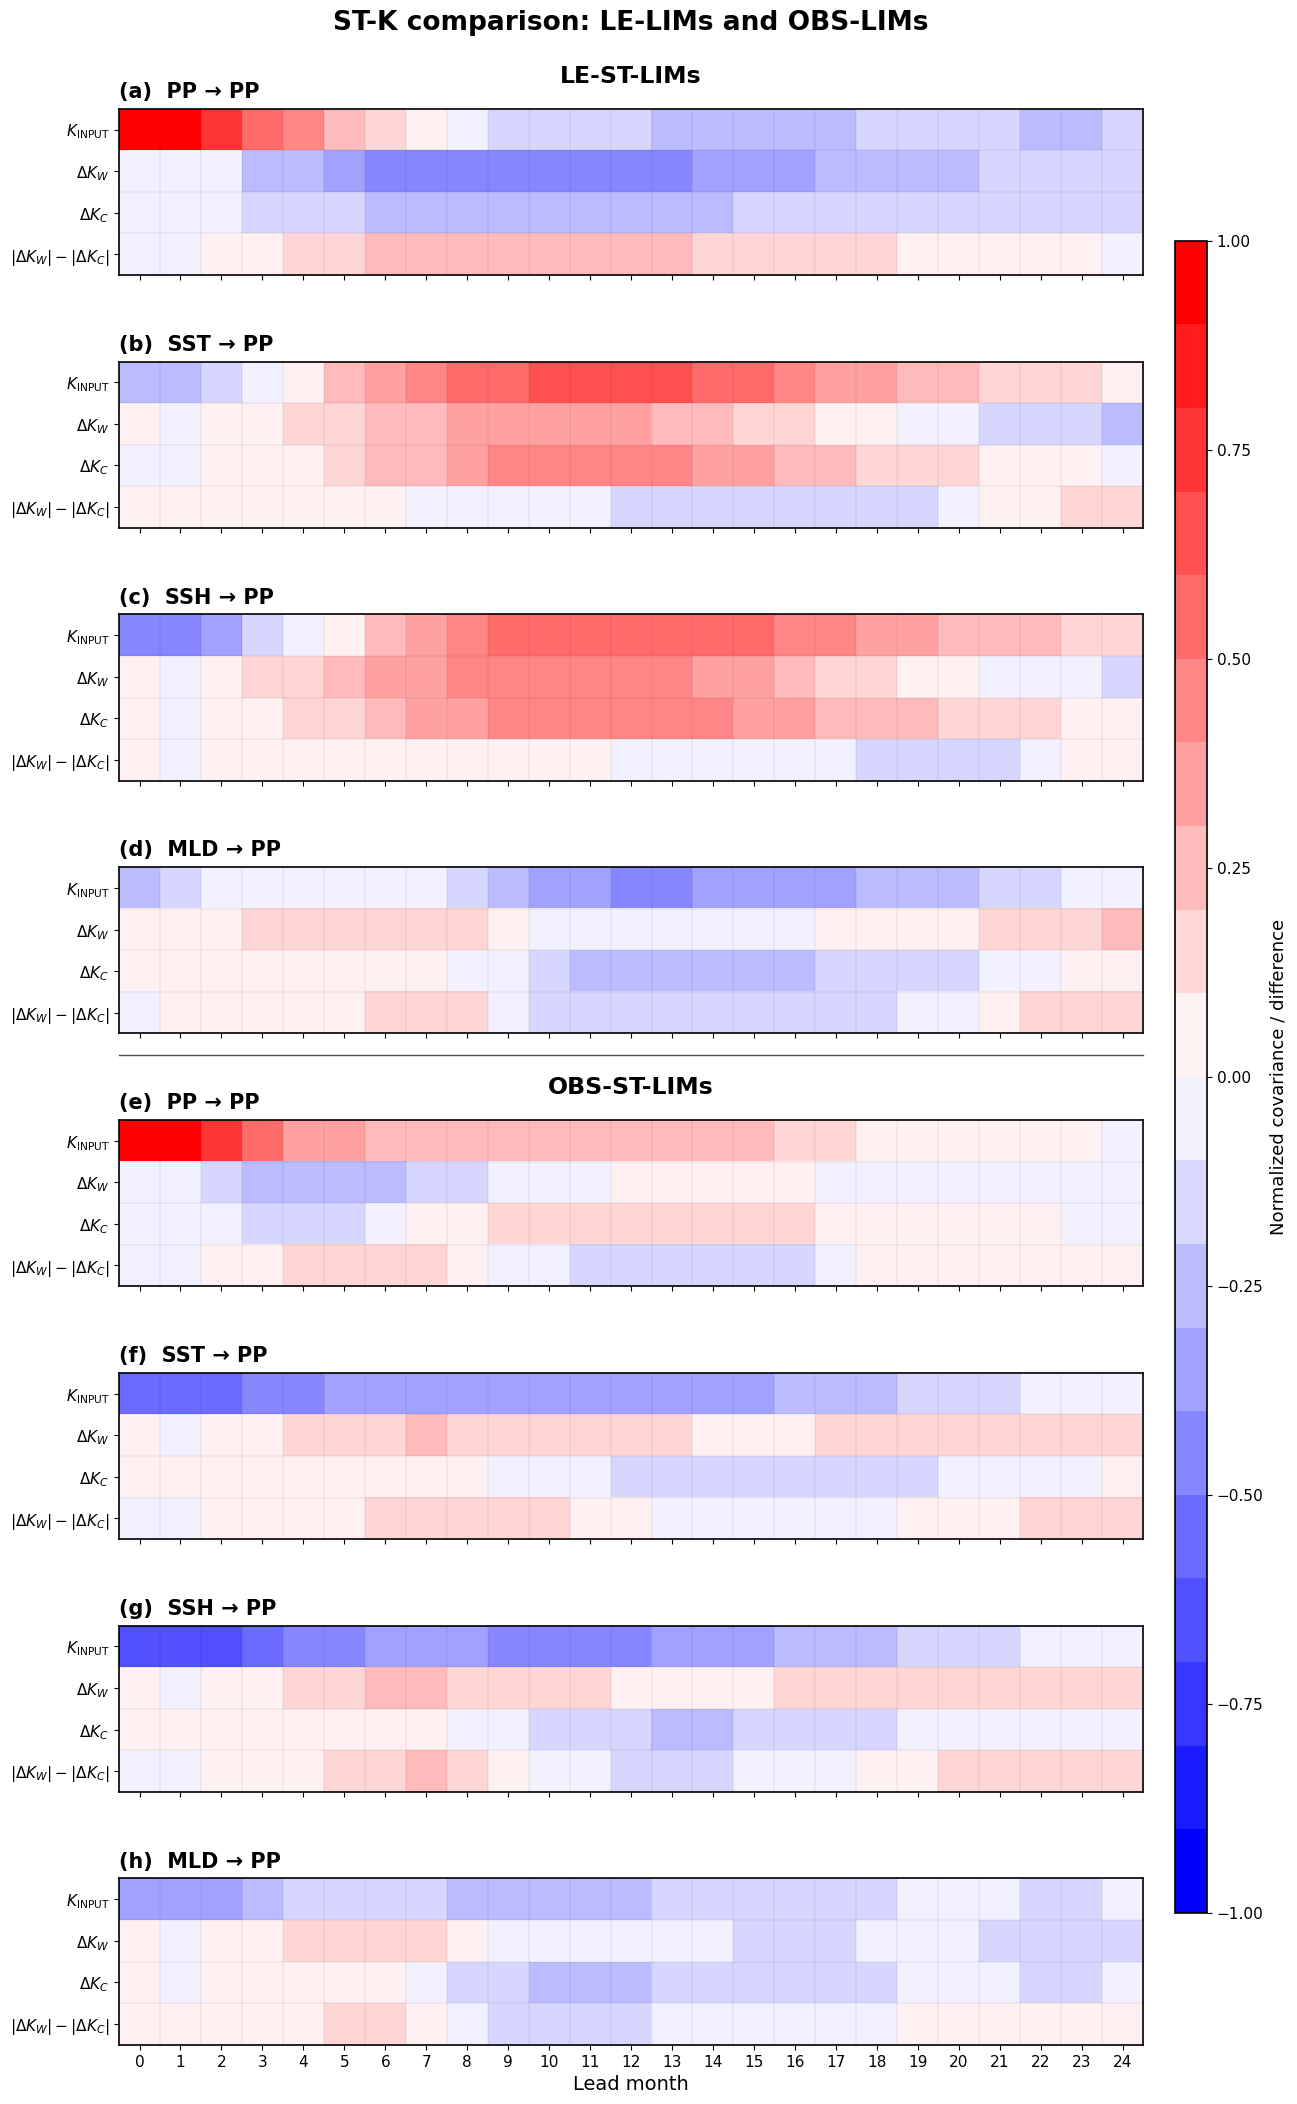

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

# Rows to plot: predictor -> target
plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),
    ("MLD", "MLD"),
]
# ---- choose 4 rows to display ----
selected_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
]

pair_keys = [f"{p}->{t}" for p, t in plot_pairs]
selected_keys = [f"{p}->{t}" for p, t in selected_pairs]

lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def check_var_exists(ds, varname):
    if varname not in ds:
        k_vars = [v for v in ds.data_vars if v.startswith("K_")]
        raise ValueError(
            f"{varname} not found in dataset.\n"
            f"Available K variables are:\n{k_vars}"
        )


def get_lead_vector(k_var, target_idx, predictor_idx, reduce_month="mean"):
    """
    Extract K[target, predictor] as [lead].

    If 'month' exists, reduce it to a single lead vector.
    Default behavior: monthly mean over 'month'.
    """
    check_var_exists(ds, k_var)

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        if reduce_month == "mean":
            da_sel = da_sel.mean(dim="month")
        elif reduce_month == "median":
            da_sel = da_sel.median(dim="month")
        else:
            raise ValueError(f"Unsupported reduce_month option: {reduce_month}")

    vec = da_sel.transpose(lead_dim).values

    return vec


def build_panel_data(k_input, k_w, k_c, plot_pairs, reduce_month="mean"):
    """
    Build panel_data for one experiment set (LE or OBS).

    Output:
        panel_data[key] = 4 x n_lead matrix
            row 0 (bottom in plot): |ΔK_W| - |ΔK_C|
            row 1:                  ΔK_C
            row 2:                  ΔK_W
            row 3 (top in plot):    K_INPUT
    """
    input_all = {}
    w_all     = {}
    c_all     = {}

    pair_keys_local = [f"{p}->{t}" for p, t in plot_pairs]

    for predictor_name, target_name in plot_pairs:
        predictor_idx = state_indices[predictor_name]
        target_idx    = state_indices[target_name]
        pair_key = f"{predictor_name}->{target_name}"

        input_all[pair_key] = get_lead_vector(
            k_input, target_idx, predictor_idx, reduce_month=reduce_month
        )
        w_all[pair_key] = get_lead_vector(
            k_w, target_idx, predictor_idx, reduce_month=reduce_month
        )
        c_all[pair_key] = get_lead_vector(
            k_c, target_idx, predictor_idx, reduce_month=reduce_month
        )

    # common lead length within this dataset
    n_lead_local = min(
        *[input_all[key].shape[0] for key in pair_keys_local],
        *[w_all[key].shape[0]     for key in pair_keys_local],
        *[c_all[key].shape[0]     for key in pair_keys_local],
    )

    for key in pair_keys_local:
        input_all[key] = input_all[key][:n_lead_local]
        w_all[key]     = w_all[key][:n_lead_local]
        c_all[key]     = c_all[key][:n_lead_local]

    panel_data = {}

    for key in pair_keys_local:
        input_k = input_all[key]
        diff_w  = input_all[key] - w_all[key]
        diff_c  = input_all[key] - c_all[key]

        # Positive means ST-Colored is closer to INPUT than ST-White
        diff_abs = np.abs(diff_w) - np.abs(diff_c)

        # origin="lower" 이므로 마지막 행이 그림의 맨 위에 표시됨
        panel_data[key] = np.vstack([
            diff_abs,   # bottom row
            diff_c,
            diff_w,
            input_k,    # top row
        ])

    return panel_data, n_lead_local


def truncate_panel_data(panel_data, n_lead_common):
    """
    Truncate all panels to a shared lead length.
    """
    panel_data_new = {}
    for key, arr in panel_data.items():
        panel_data_new[key] = arr[:, :n_lead_common]
    return panel_data_new


# ============================================================
# 3. Build LE / OBS panel data
# ============================================================

# LE
panel_data_le, n_lead_le = build_panel_data(
    k_input="K_ST_OBS_LE",
    k_w="K_ST_W_LE",
    k_c="K_ST_C_LE",
    plot_pairs=plot_pairs,
    reduce_month="mean",
)

# OBS
panel_data_obs, n_lead_obs = build_panel_data(
    k_input="K_ST_OBS_OBS",
    k_w="K_ST_W_OBS",
    k_c="K_ST_C_OBS",
    plot_pairs=plot_pairs,
    reduce_month="mean",
)

# shared lead length across LE and OBS
n_lead = min(n_lead_le, n_lead_obs)

panel_data_le  = truncate_panel_data(panel_data_le,  n_lead)
panel_data_obs = truncate_panel_data(panel_data_obs, n_lead)

pair_keys = [f"{p}->{t}" for p, t in plot_pairs]
lead_vals = np.arange(n_lead)


# ============================================================
# 4. Row labels inside each panel
# ============================================================

row_labels_inside_panel = [
    r"$|\Delta K_W| - |\Delta K_C|$",
    r"$\Delta K_C$",
    r"$\Delta K_W$",
    r"$K_{\mathrm{INPUT}}$",
]


# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],   # blue
    [1, 1, 1],   # white
    [1, 0, 0],   # red
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Common color range across selected LE + OBS panels
# ============================================================

all_values = np.concatenate([
    panel_data_le[key][np.isfinite(panel_data_le[key])].ravel()
    for key in selected_keys
] + [
    panel_data_obs[key][np.isfinite(panel_data_obs[key])].ravel()
    for key in selected_keys
])

vlim = np.nanmax(np.abs(all_values))
vlim = np.ceil(vlim * 20) / 20

# Manual override
vlim = 1.0

if vlim == 0:
    vlim = 0.1


# ============================================================
# 7. Combine rows: upper 4 = LE, lower 4 = OBS
# ============================================================

combined_rows = []

# (a)~(d): LE
for pair in selected_pairs:
    combined_rows.append({
        "group": "LE",
        "pair": pair,
        "key": f"{pair[0]}->{pair[1]}",
    })

# (e)~(h): OBS
for pair in selected_pairs:
    combined_rows.append({
        "group": "OBS",
        "pair": pair,
        "key": f"{pair[0]}->{pair[1]}",
    })

row_letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]


# ============================================================
# 8. Plot: 8 panels, one target-predictor pair per panel
# ============================================================

n_panel = len(combined_rows)   # 8

fig, axes = plt.subplots(
    n_panel, 1,
    figsize=(16, 22),
    sharex=True,
)

if n_panel == 1:
    axes = [axes]

fig.subplots_adjust(
    left=0.24,
    right=0.88,
    bottom=0.06,
    top=0.94,
    hspace=0.52,
)

im = None

for i, row_info in enumerate(combined_rows):

    predictor_name, target_name = row_info["pair"]
    key = row_info["key"]

    if row_info["group"] == "LE":
        M = panel_data_le[key]
    else:
        M = panel_data_obs[key]

    ax = axes[i]

    im = ax.imshow(
        M,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-vlim,
        vmax=vlim,
        interpolation="none",
    )

    ax.set_yticks(np.arange(4))
    ax.set_yticklabels(row_labels_inside_panel)

    ax.set_title(
        f"{row_letters[i]}  {predictor_name} → {target_name}",
        fontsize=15,
        fontweight="bold",
        pad=8,
        loc="left",
    )

    # Grid
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, n_lead, 1), minor=True)

    ax.grid(
        which="minor",
        color="k",
        linestyle="-",
        linewidth=0.25,
        alpha=0.25,
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    if i == n_panel - 1:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels(lead_vals)
        ax.set_xlabel("Lead month")
    else:
        ax.set_xticks(np.arange(n_lead))
        ax.set_xticklabels([])


# ============================================================
# 9. Group titles and separator
# ============================================================

fig.text(
    0.56, 0.955,
    "LE-ST-LIMs",
    ha="center", va="center",
    fontsize=17, fontweight="bold"
)

fig.text(
    0.56, 0.495,
    "OBS-ST-LIMs",
    ha="center", va="center",
    fontsize=17, fontweight="bold"
)

fig.lines.append(
    plt.Line2D(
        [0.24, 0.88], [0.510, 0.510],
        transform=fig.transFigure,
        color="k",
        linewidth=1.0,
        alpha=0.7,
    )
)


# ============================================================
# 10. One shared colorbar
# ============================================================

cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label("Normalized covariance / difference", fontsize=13)


# ============================================================
# 11. Suptitle
# ============================================================

fig.suptitle(
    "ST-K comparison: LE-LIMs and OBS-LIMs",
    fontsize=19,
    fontweight="bold",
    x=0.56, y=0.985,
)

plt.show()

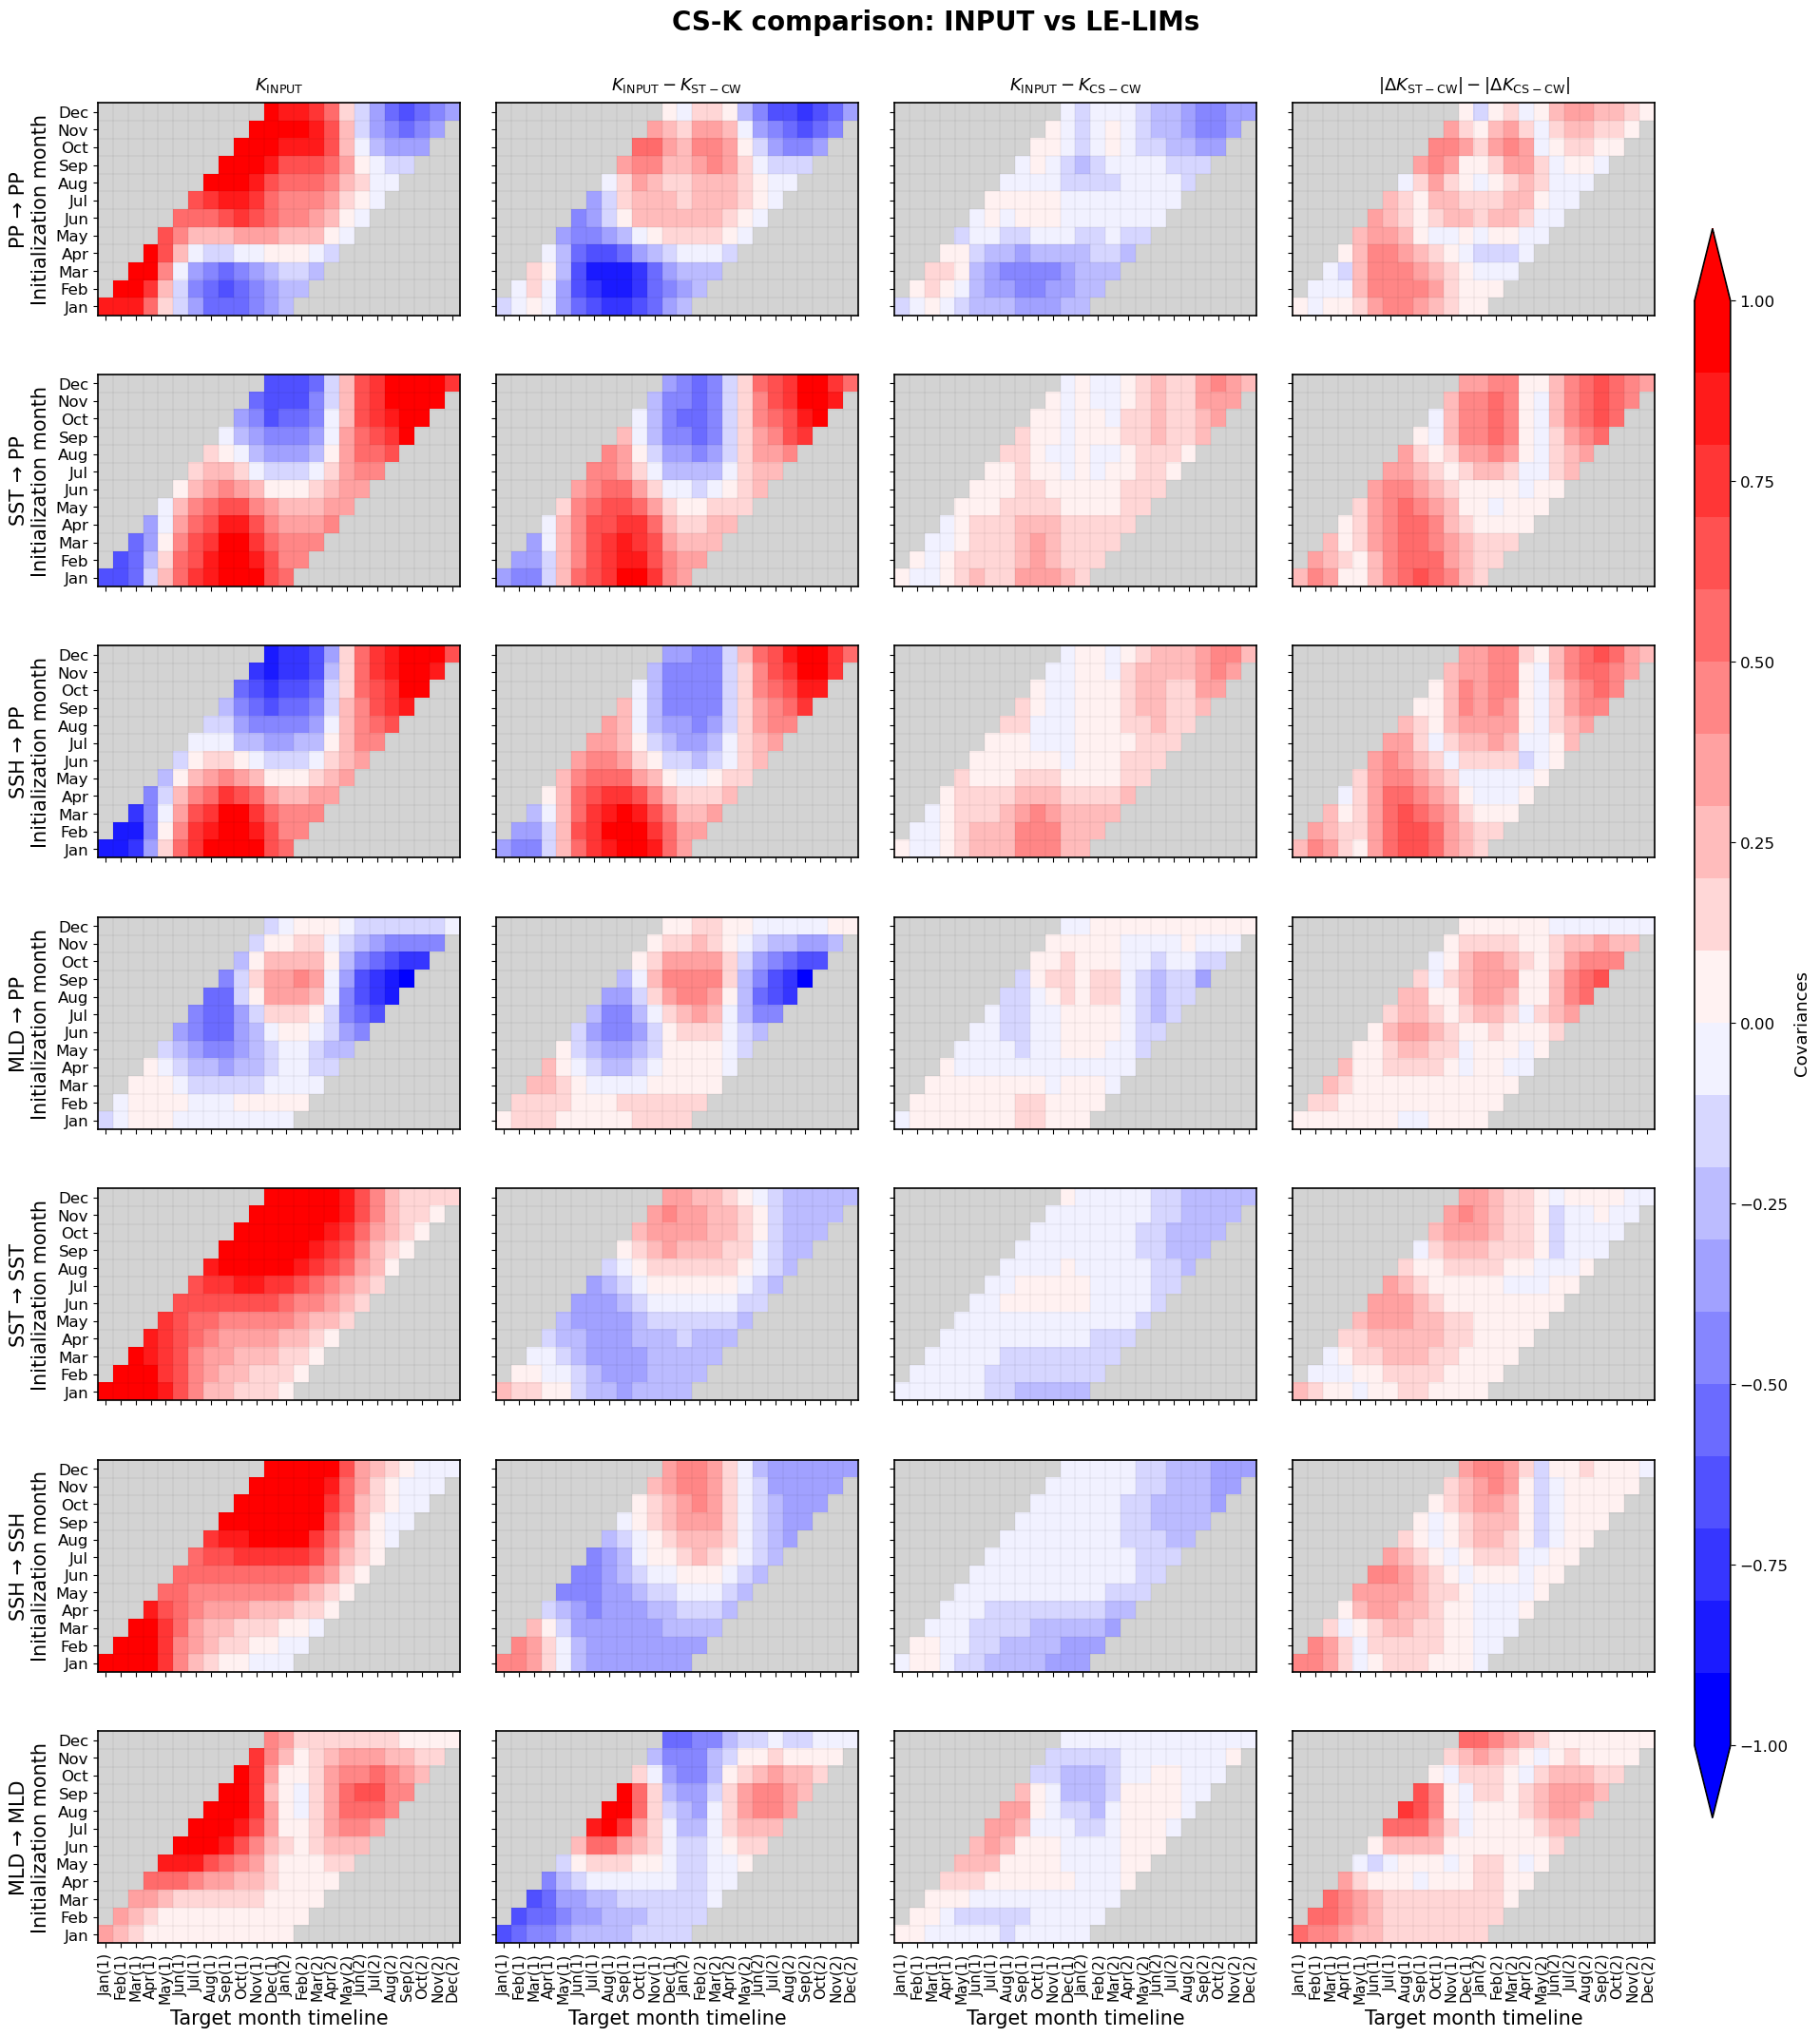

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

# Rows to plot: predictor -> target
plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),   # Change to ("SSH", "SSH") if needed
    ("MLD", "MLD"),
]

pair_keys = [f"{p}->{t}" for p, t in plot_pairs]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]

# Only plot lead months 0–12
MAX_LEAD_MONTH = 12


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def check_var_exists(ds, varname):
    if varname not in ds:
        k_vars = [v for v in ds.data_vars if v.startswith("K_")]
        raise ValueError(
            f"{varname} not found in dataset.\n"
            f"Available K variables are:\n{k_vars}"
        )


def get_month_lead_matrix(k_var, target_idx, predictor_idx):
    """
    Extract K[target, predictor] as [month, lead].

    If the variable has no 'month' dimension, repeat the same
    [lead] vector for all 12 initialization months.
    """

    check_var_exists(ds, k_var)

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        C = da_sel.transpose("month", lead_dim).values
    else:
        C_lead = da_sel.transpose(lead_dim).values
        C = np.tile(C_lead[None, :], (n_month, 1))

    return C


def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """

    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


def make_target_month_labels(max_lag):
    labels = []
    year = 1

    for i in range(max_lag + 12):
        mo = i % 12
        if i > 0 and mo == 0:
            year += 1
        labels.append(f"{month_names[mo]}({year})")

    return labels


# ============================================================
# 3. Load matrices
# ============================================================

k_input = "K_CS_OBS_LE"     # INPUT K
k_st_cw = "K_ST_CW_LE"      # ST-CW LIM K
k_cs_cw = "K_CS_CW_LE"      # CS-CW LIM K

C_input_all = {}
C_stcw_all  = {}
C_cscw_all  = {}

for predictor_name, target_name in plot_pairs:

    predictor_idx = state_indices[predictor_name]
    target_idx    = state_indices[target_name]

    pair_key = f"{predictor_name}->{target_name}"

    C_input_all[pair_key] = get_month_lead_matrix(
        k_input, target_idx, predictor_idx
    )

    C_stcw_all[pair_key] = get_month_lead_matrix(
        k_st_cw, target_idx, predictor_idx
    )

    C_cscw_all[pair_key] = get_month_lead_matrix(
        k_cs_cw, target_idx, predictor_idx
    )


# Use common lead length across all pairs and variables
n_lead_available = min(
    *[C_input_all[key].shape[1] for key in pair_keys],
    *[C_stcw_all[key].shape[1]  for key in pair_keys],
    *[C_cscw_all[key].shape[1]  for key in pair_keys],
)

# Keep only lead 0–12
n_lead = min(MAX_LEAD_MONTH + 1, n_lead_available)
max_lag = n_lead - 1

for key in pair_keys:
    C_input_all[key] = C_input_all[key][:, :n_lead]
    C_stcw_all[key]  = C_stcw_all[key][:, :n_lead]
    C_cscw_all[key]  = C_cscw_all[key][:, :n_lead]

labels = make_target_month_labels(max_lag)


# ============================================================
# 4. Build panel matrices
# ============================================================

panel_titles = [
    r"$K_{\mathrm{INPUT}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{ST-CW}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{CS-CW}}$",
    r"$|\Delta K_{\mathrm{ST-CW}}| - |\Delta K_{\mathrm{CS-CW}}|$",
]

panel_data = {}

for key in pair_keys:

    input_k = C_input_all[key]

    diff_stcw = C_input_all[key] - C_stcw_all[key]
    diff_cscw = C_input_all[key] - C_cscw_all[key]

    # Positive means CS-CW is closer to INPUT than ST-CW
    diff_abs = np.abs(diff_stcw) - np.abs(diff_cscw)

    panel_data[key] = [
        input_k,
        diff_stcw,
        diff_cscw,
        diff_abs,
    ]


# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 0],
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Color ranges
# ============================================================

vlim_input = 1.0

diff_values = []

for key in pair_keys:
    for arr in panel_data[key][1:]:
        diff_values.append(arr[np.isfinite(arr)].ravel())

diff_values = np.concatenate(diff_values)

vlim_diff = np.nanmax(np.abs(diff_values))
vlim_diff = np.ceil(vlim_diff * 20) / 20

# Manual override
vlim_diff = 0.5

if vlim_diff == 0:
    vlim_diff = 0.1


# ============================================================
# 7. Plot: 7 rows x 4 columns
# ============================================================

n_row = len(pair_keys)
n_col = 4

fig, axes = plt.subplots(
    n_row, n_col,
    figsize=(21, 22),
    sharex=True,
    sharey=True,
)

fig.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.06,
    top=0.94,
    wspace=0.10,
    hspace=0.28,
)

im_input = None
im_diff = None

for irow, ((predictor_name, target_name), key) in enumerate(zip(plot_pairs, pair_keys)):
    for icol in range(n_col):

        ax = axes[irow, icol]

        Cplot = panel_data[key][icol]
        skill = shifted_target_matrix(Cplot, max_lag)
        masked = np.ma.masked_invalid(skill)

        vmin, vmax = -vlim_input, vlim_input

        im = ax.imshow(
            masked,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="none",
        )

        if icol == 0:
            im_input = im
        else:
            im_diff = im

        # Column titles
        if irow == 0:
            ax.set_title(
                panel_titles[icol],
                fontsize=13,
                fontweight="bold",
                pad=10,
            )

        # Row labels
        if icol == 0:
            ax.set_ylabel(
                f"{predictor_name} → {target_name}\nInitialization month"
            )

        # Y ticks
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(month_names)

        # Grid lines
        ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
        ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)

        ax.grid(
            which="minor",
            color="k",
            linestyle="-",
            linewidth=0.25,
            alpha=0.20,
        )

        ax.tick_params(which="minor", bottom=False, left=False)

        # Bottom x labels only
        if irow == n_row - 1:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=90)
            ax.set_xlabel("Target month timeline")
        else:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels([])


# ============================================================
# 8. Colorbars
# ============================================================

# Colorbar for INPUT K
cax1 = fig.add_axes([0.88, 0.12, 0.018, 0.76])
cbar1 = fig.colorbar(
    im,
    cax=cax1,
    extend="both",
)
cbar1.set_label("Covariances", fontsize=13)

# # Colorbar for difference panels
# cax2 = fig.add_axes([0.925, 0.12, 0.018, 0.76])
# cbar2 = fig.colorbar(
#     im_diff,
#     cax=cax2,
#     extend="both",
# )
# cbar2.set_label("Difference", fontsize=13)


fig.suptitle(
    "CS-K comparison: INPUT vs LE-LIMs",
    fontsize=20,
    fontweight="bold",
    y=0.985,
)

plt.show()

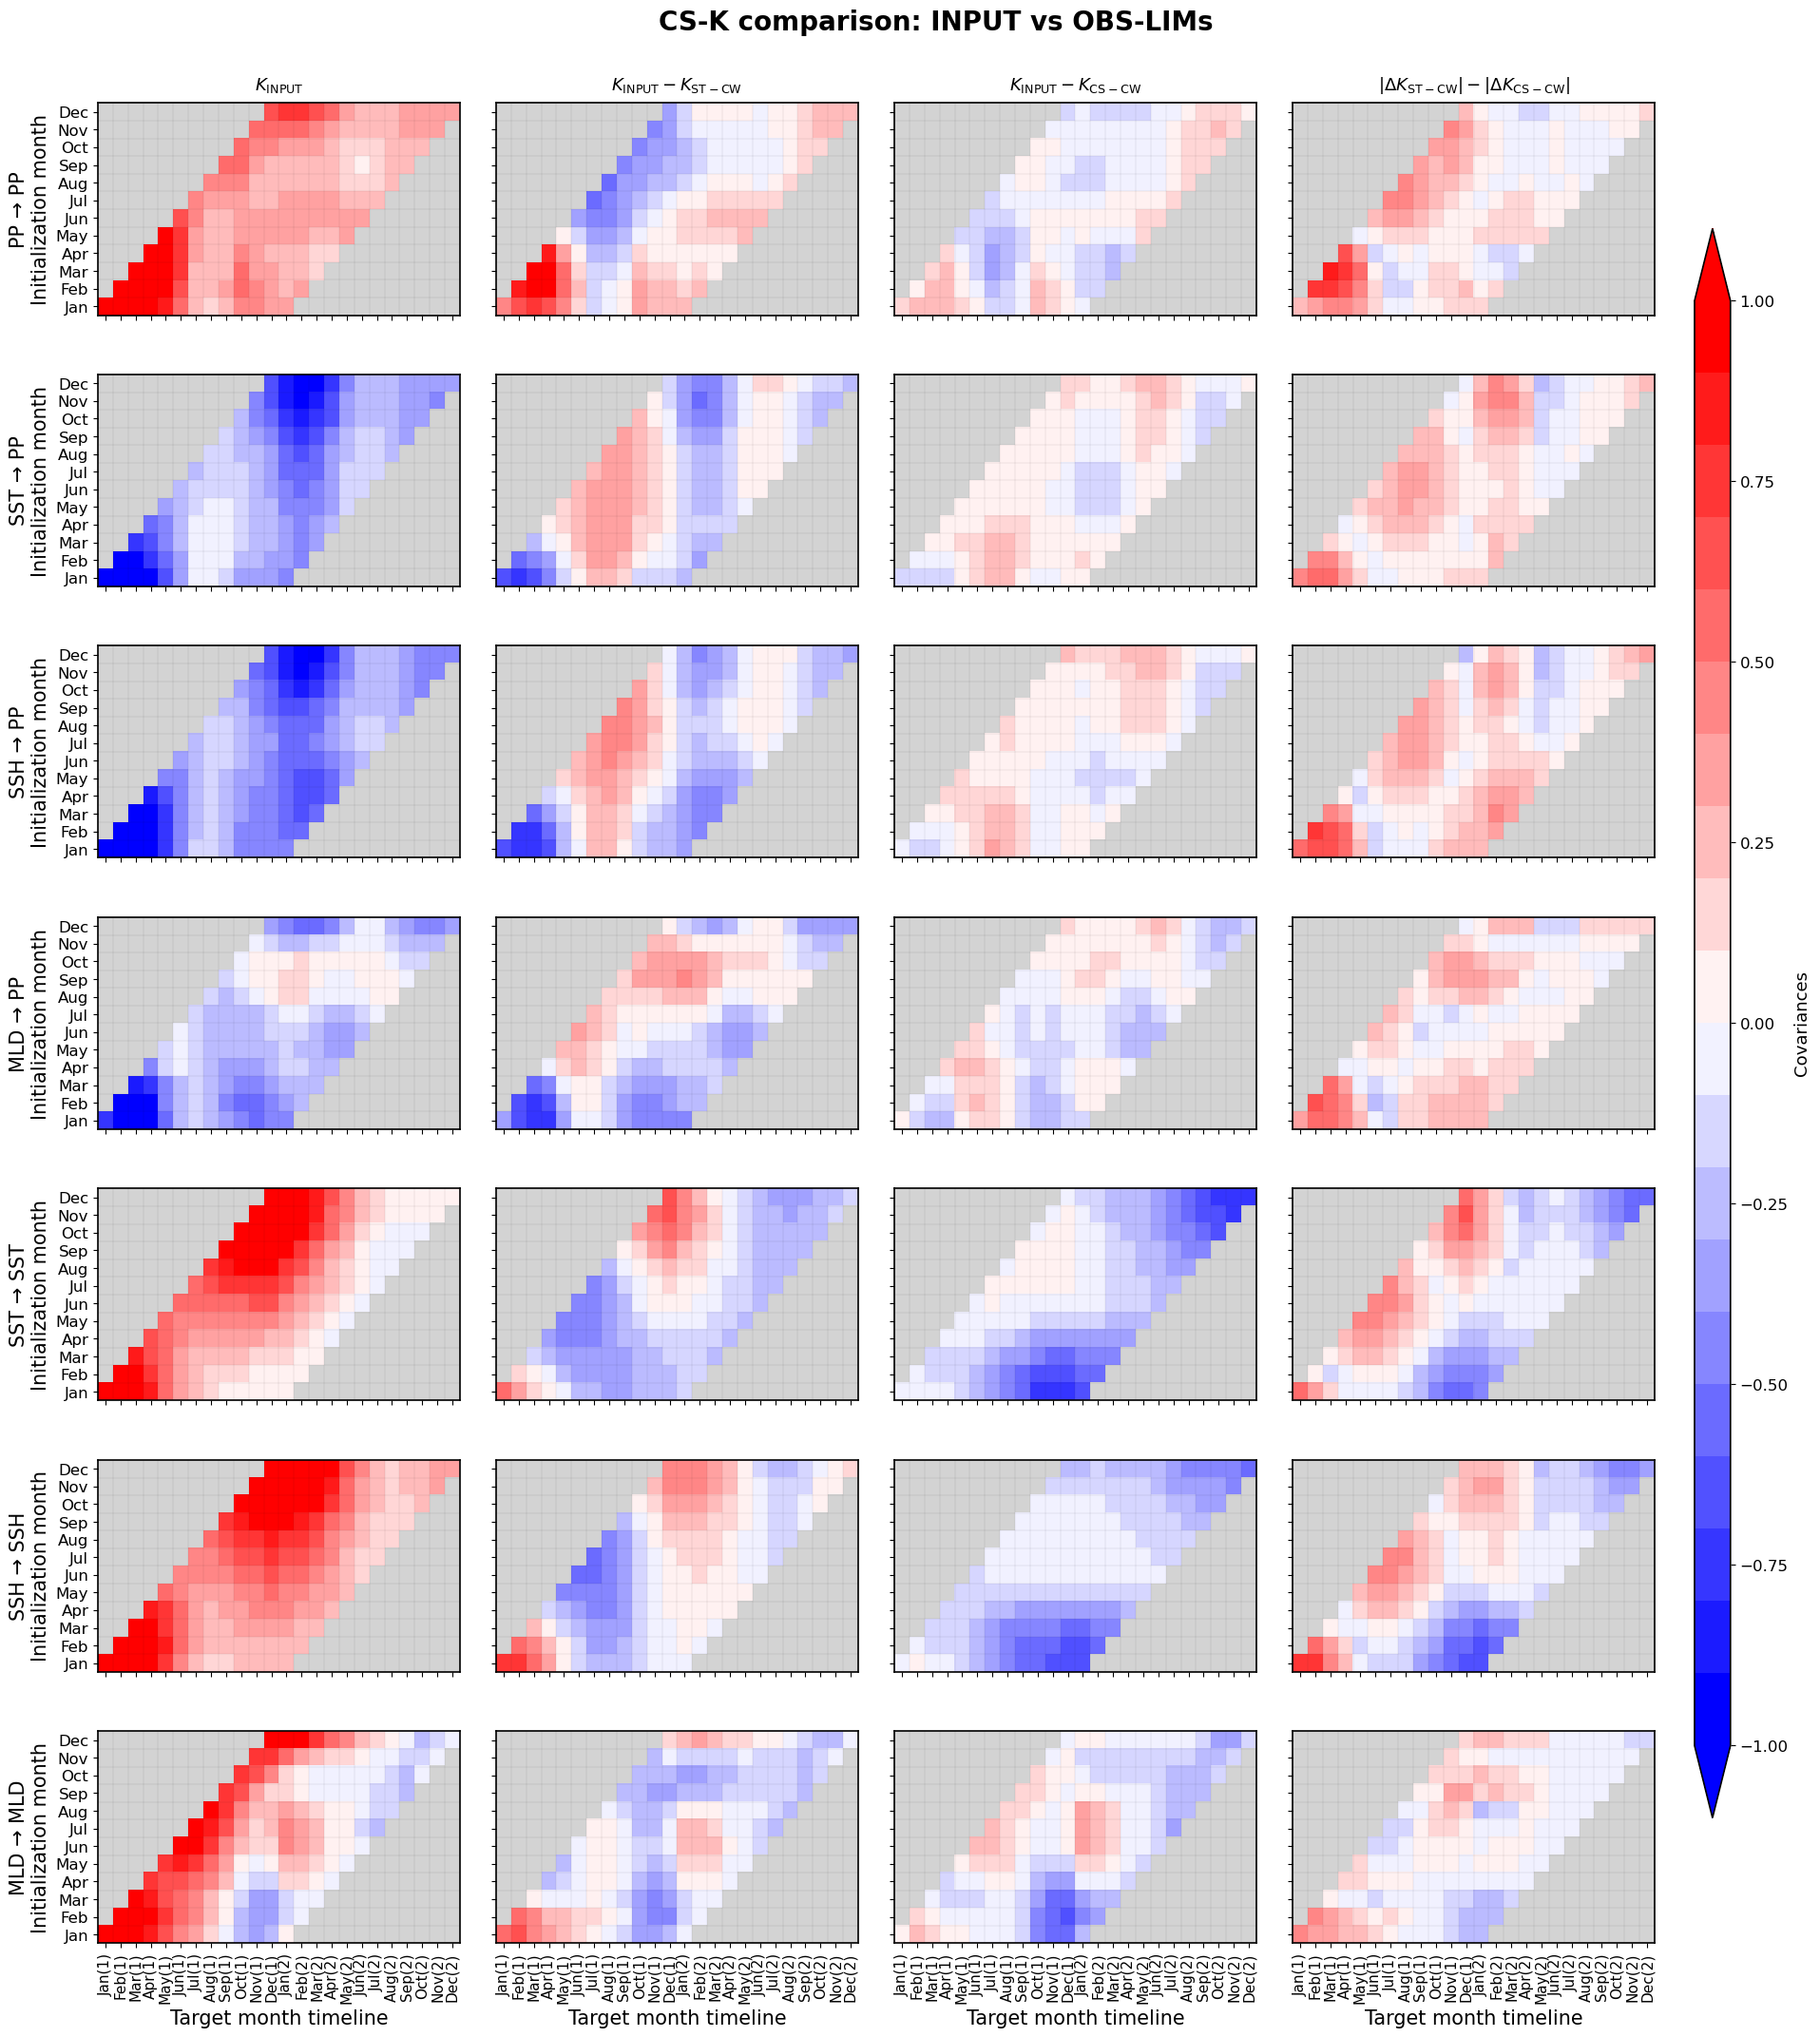

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

# Rows to plot: predictor -> target
plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),   # Change to ("SSH", "SSH") if needed
    ("MLD", "MLD"),
]

pair_keys = [f"{p}->{t}" for p, t in plot_pairs]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]

# Only plot lead months 0–12
MAX_LEAD_MONTH = 12


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def check_var_exists(ds, varname):
    if varname not in ds:
        k_vars = [v for v in ds.data_vars if v.startswith("K_")]
        raise ValueError(
            f"{varname} not found in dataset.\n"
            f"Available K variables are:\n{k_vars}"
        )


def get_month_lead_matrix(k_var, target_idx, predictor_idx):
    """
    Extract K[target, predictor] as [month, lead].

    If the variable has no 'month' dimension, repeat the same
    [lead] vector for all 12 initialization months.
    """

    check_var_exists(ds, k_var)

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        C = da_sel.transpose("month", lead_dim).values
    else:
        C_lead = da_sel.transpose(lead_dim).values
        C = np.tile(C_lead[None, :], (n_month, 1))

    return C


def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """

    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


def make_target_month_labels(max_lag):
    labels = []
    year = 1

    for i in range(max_lag + 12):
        mo = i % 12
        if i > 0 and mo == 0:
            year += 1
        labels.append(f"{month_names[mo]}({year})")

    return labels


# ============================================================
# 3. Load matrices
# ============================================================

k_input = "K_CS_OBS_OBS"     # INPUT K
k_st_cw = "K_ST_CW_OBS"      # ST-CW LIM K
k_cs_cw = "K_CS_CW_OBS"      # CS-CW LIM K

C_input_all = {}
C_stcw_all  = {}
C_cscw_all  = {}

for predictor_name, target_name in plot_pairs:

    predictor_idx = state_indices[predictor_name]
    target_idx    = state_indices[target_name]

    pair_key = f"{predictor_name}->{target_name}"

    C_input_all[pair_key] = get_month_lead_matrix(
        k_input, target_idx, predictor_idx
    )

    C_stcw_all[pair_key] = get_month_lead_matrix(
        k_st_cw, target_idx, predictor_idx
    )

    C_cscw_all[pair_key] = get_month_lead_matrix(
        k_cs_cw, target_idx, predictor_idx
    )


# Use common lead length across all pairs and variables
n_lead_available = min(
    *[C_input_all[key].shape[1] for key in pair_keys],
    *[C_stcw_all[key].shape[1]  for key in pair_keys],
    *[C_cscw_all[key].shape[1]  for key in pair_keys],
)

# Keep only lead 0–12
n_lead = min(MAX_LEAD_MONTH + 1, n_lead_available)
max_lag = n_lead - 1

for key in pair_keys:
    C_input_all[key] = C_input_all[key][:, :n_lead]
    C_stcw_all[key]  = C_stcw_all[key][:, :n_lead]
    C_cscw_all[key]  = C_cscw_all[key][:, :n_lead]

labels = make_target_month_labels(max_lag)


# ============================================================
# 4. Build panel matrices
# ============================================================

panel_titles = [
    r"$K_{\mathrm{INPUT}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{ST-CW}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{CS-CW}}$",
    r"$|\Delta K_{\mathrm{ST-CW}}| - |\Delta K_{\mathrm{CS-CW}}|$",
]

panel_data = {}

for key in pair_keys:

    input_k = C_input_all[key]

    diff_stcw = C_input_all[key] - C_stcw_all[key]
    diff_cscw = C_input_all[key] - C_cscw_all[key]

    # Positive means CS-CW is closer to INPUT than ST-CW
    diff_abs = np.abs(diff_stcw) - np.abs(diff_cscw)

    panel_data[key] = [
        input_k,
        diff_stcw,
        diff_cscw,
        diff_abs,
    ]


# ============================================================
# 5. Blue-white-red colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 0],
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))

for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 6. Color ranges
# ============================================================

vlim_input = 1.0

diff_values = []

for key in pair_keys:
    for arr in panel_data[key][1:]:
        diff_values.append(arr[np.isfinite(arr)].ravel())

diff_values = np.concatenate(diff_values)

vlim_diff = np.nanmax(np.abs(diff_values))
vlim_diff = np.ceil(vlim_diff * 20) / 20

# Manual override
vlim_diff = 0.5

if vlim_diff == 0:
    vlim_diff = 0.1


# ============================================================
# 7. Plot: 7 rows x 4 columns
# ============================================================

n_row = len(pair_keys)
n_col = 4

fig, axes = plt.subplots(
    n_row, n_col,
    figsize=(21, 22),
    sharex=True,
    sharey=True,
)

fig.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.06,
    top=0.94,
    wspace=0.10,
    hspace=0.28,
)

im_input = None
im_diff = None

for irow, ((predictor_name, target_name), key) in enumerate(zip(plot_pairs, pair_keys)):
    for icol in range(n_col):

        ax = axes[irow, icol]

        Cplot = panel_data[key][icol]
        skill = shifted_target_matrix(Cplot, max_lag)
        masked = np.ma.masked_invalid(skill)

        vmin, vmax = -vlim_input, vlim_input

        im = ax.imshow(
            masked,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="none",
        )

        if icol == 0:
            im_input = im
        else:
            im_diff = im

        # Column titles
        if irow == 0:
            ax.set_title(
                panel_titles[icol],
                fontsize=13,
                fontweight="bold",
                pad=10,
            )

        # Row labels
        if icol == 0:
            ax.set_ylabel(
                f"{predictor_name} → {target_name}\nInitialization month"
            )

        # Y ticks
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(month_names)

        # Grid lines
        ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
        ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)

        ax.grid(
            which="minor",
            color="k",
            linestyle="-",
            linewidth=0.25,
            alpha=0.20,
        )

        ax.tick_params(which="minor", bottom=False, left=False)

        # Bottom x labels only
        if irow == n_row - 1:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=90)
            ax.set_xlabel("Target month timeline")
        else:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels([])


# ============================================================
# 8. Colorbars
# ============================================================

# Colorbar for INPUT K
cax1 = fig.add_axes([0.88, 0.12, 0.018, 0.76])
cbar1 = fig.colorbar(
    im,
    cax=cax1,
    extend="both",
)
cbar1.set_label("Covariances", fontsize=13)

# # Colorbar for difference panels
# cax2 = fig.add_axes([0.925, 0.12, 0.018, 0.76])
# cbar2 = fig.colorbar(
#     im_diff,
#     cax=cax2,
#     extend="both",
# )
# cbar2.set_label("Difference", fontsize=13)


fig.suptitle(
    "CS-K comparison: INPUT vs OBS-LIMs",
    fontsize=20,
    fontweight="bold",
    y=0.985,
)

plt.show()

In [61]:
def inspect_lead_and_autocorr(k_var, state_name):
    da = ds[k_var]
    da = mean_over_ensemble(da)

    lead_dim = find_lead_dim(da)
    state_idx = predictor_indices[state_name]

    if lead_dim in da.coords:
        lead_vals = da[lead_dim].values
    else:
        lead_vals = np.arange(da.sizes[lead_dim])

    K_auto = (
        da
        .isel(state_i=state_idx, state_j=state_idx)
        .squeeze(drop=True)
    )

    print(f"\n{k_var}, {state_name}->{state_name}")
    print("lead_dim:", lead_dim)
    print("first lead values:", lead_vals[:10])

    if "month" in K_auto.dims:
        K_arr = K_auto.transpose("month", lead_dim).values

        print("values at first lead index:")
        for im, mo in enumerate(month_names):
            print(mo, K_arr[im, 0])

        print("\nlead index/value closest to 1:")
        for im, mo in enumerate(month_names):
            idx = np.nanargmin(np.abs(K_arr[im, :] - 1.0))
            print(
                mo,
                "idx =", idx,
                "lead =", lead_vals[idx],
                "K =", K_arr[im, idx],
            )

    else:
        K_arr = K_auto.transpose(lead_dim).values
        idx = np.nanargmin(np.abs(K_arr - 1.0))
        print("values at first lead index:", K_arr[0])
        print("closest to 1: idx =", idx, "lead =", lead_vals[idx], "K =", K_arr[idx])


inspect_lead_and_autocorr("K_CS_OBS_LE", "PP")
inspect_lead_and_autocorr("K_CS_OBS_LE", "SST")
inspect_lead_and_autocorr("K_CS_OBS_LE", "SSH")
inspect_lead_and_autocorr("K_CS_OBS_LE", "MLD")


K_CS_OBS_LE, PP->PP
lead_dim: lead
first lead values: [0 1 2 3 4 5 6 7 8 9]
values at first lead index:
Jan 0.8235328163752793
Feb 0.9783805398772837
Mar 1.133844851477912
Apr 0.9011015383126673
May 0.6144379485351638
Jun 0.590532619190228
Jul 0.695885707213311
Aug 0.9309541542290667
Sep 1.3670608655778644
Oct 1.5588134327753493
Nov 1.3554358332461456
Dec 1.0500196931897292

lead index/value closest to 1:
Jan idx = 1 lead = 1 K = 0.8488361203746806
Feb idx = 1 lead = 1 K = 0.9890741534860278
Mar idx = 1 lead = 1 K = 0.9131980808468829
Apr idx = 0 lead = 0 K = 0.9011015383126673
May idx = 0 lead = 0 K = 0.6144379485351638
Jun idx = 4 lead = 4 K = 0.7221743457598342
Jul idx = 2 lead = 2 K = 0.8681726374150331
Aug idx = 2 lead = 2 K = 1.0586554871995917
Sep idx = 3 lead = 3 K = 0.8353089015842301
Oct idx = 2 lead = 2 K = 1.0975063223273203
Nov idx = 2 lead = 2 K = 0.9262117199672951
Dec idx = 0 lead = 0 K = 1.0500196931897292

K_CS_OBS_LE, SST->SST
lead_dim: lead
first lead values: [0 1 

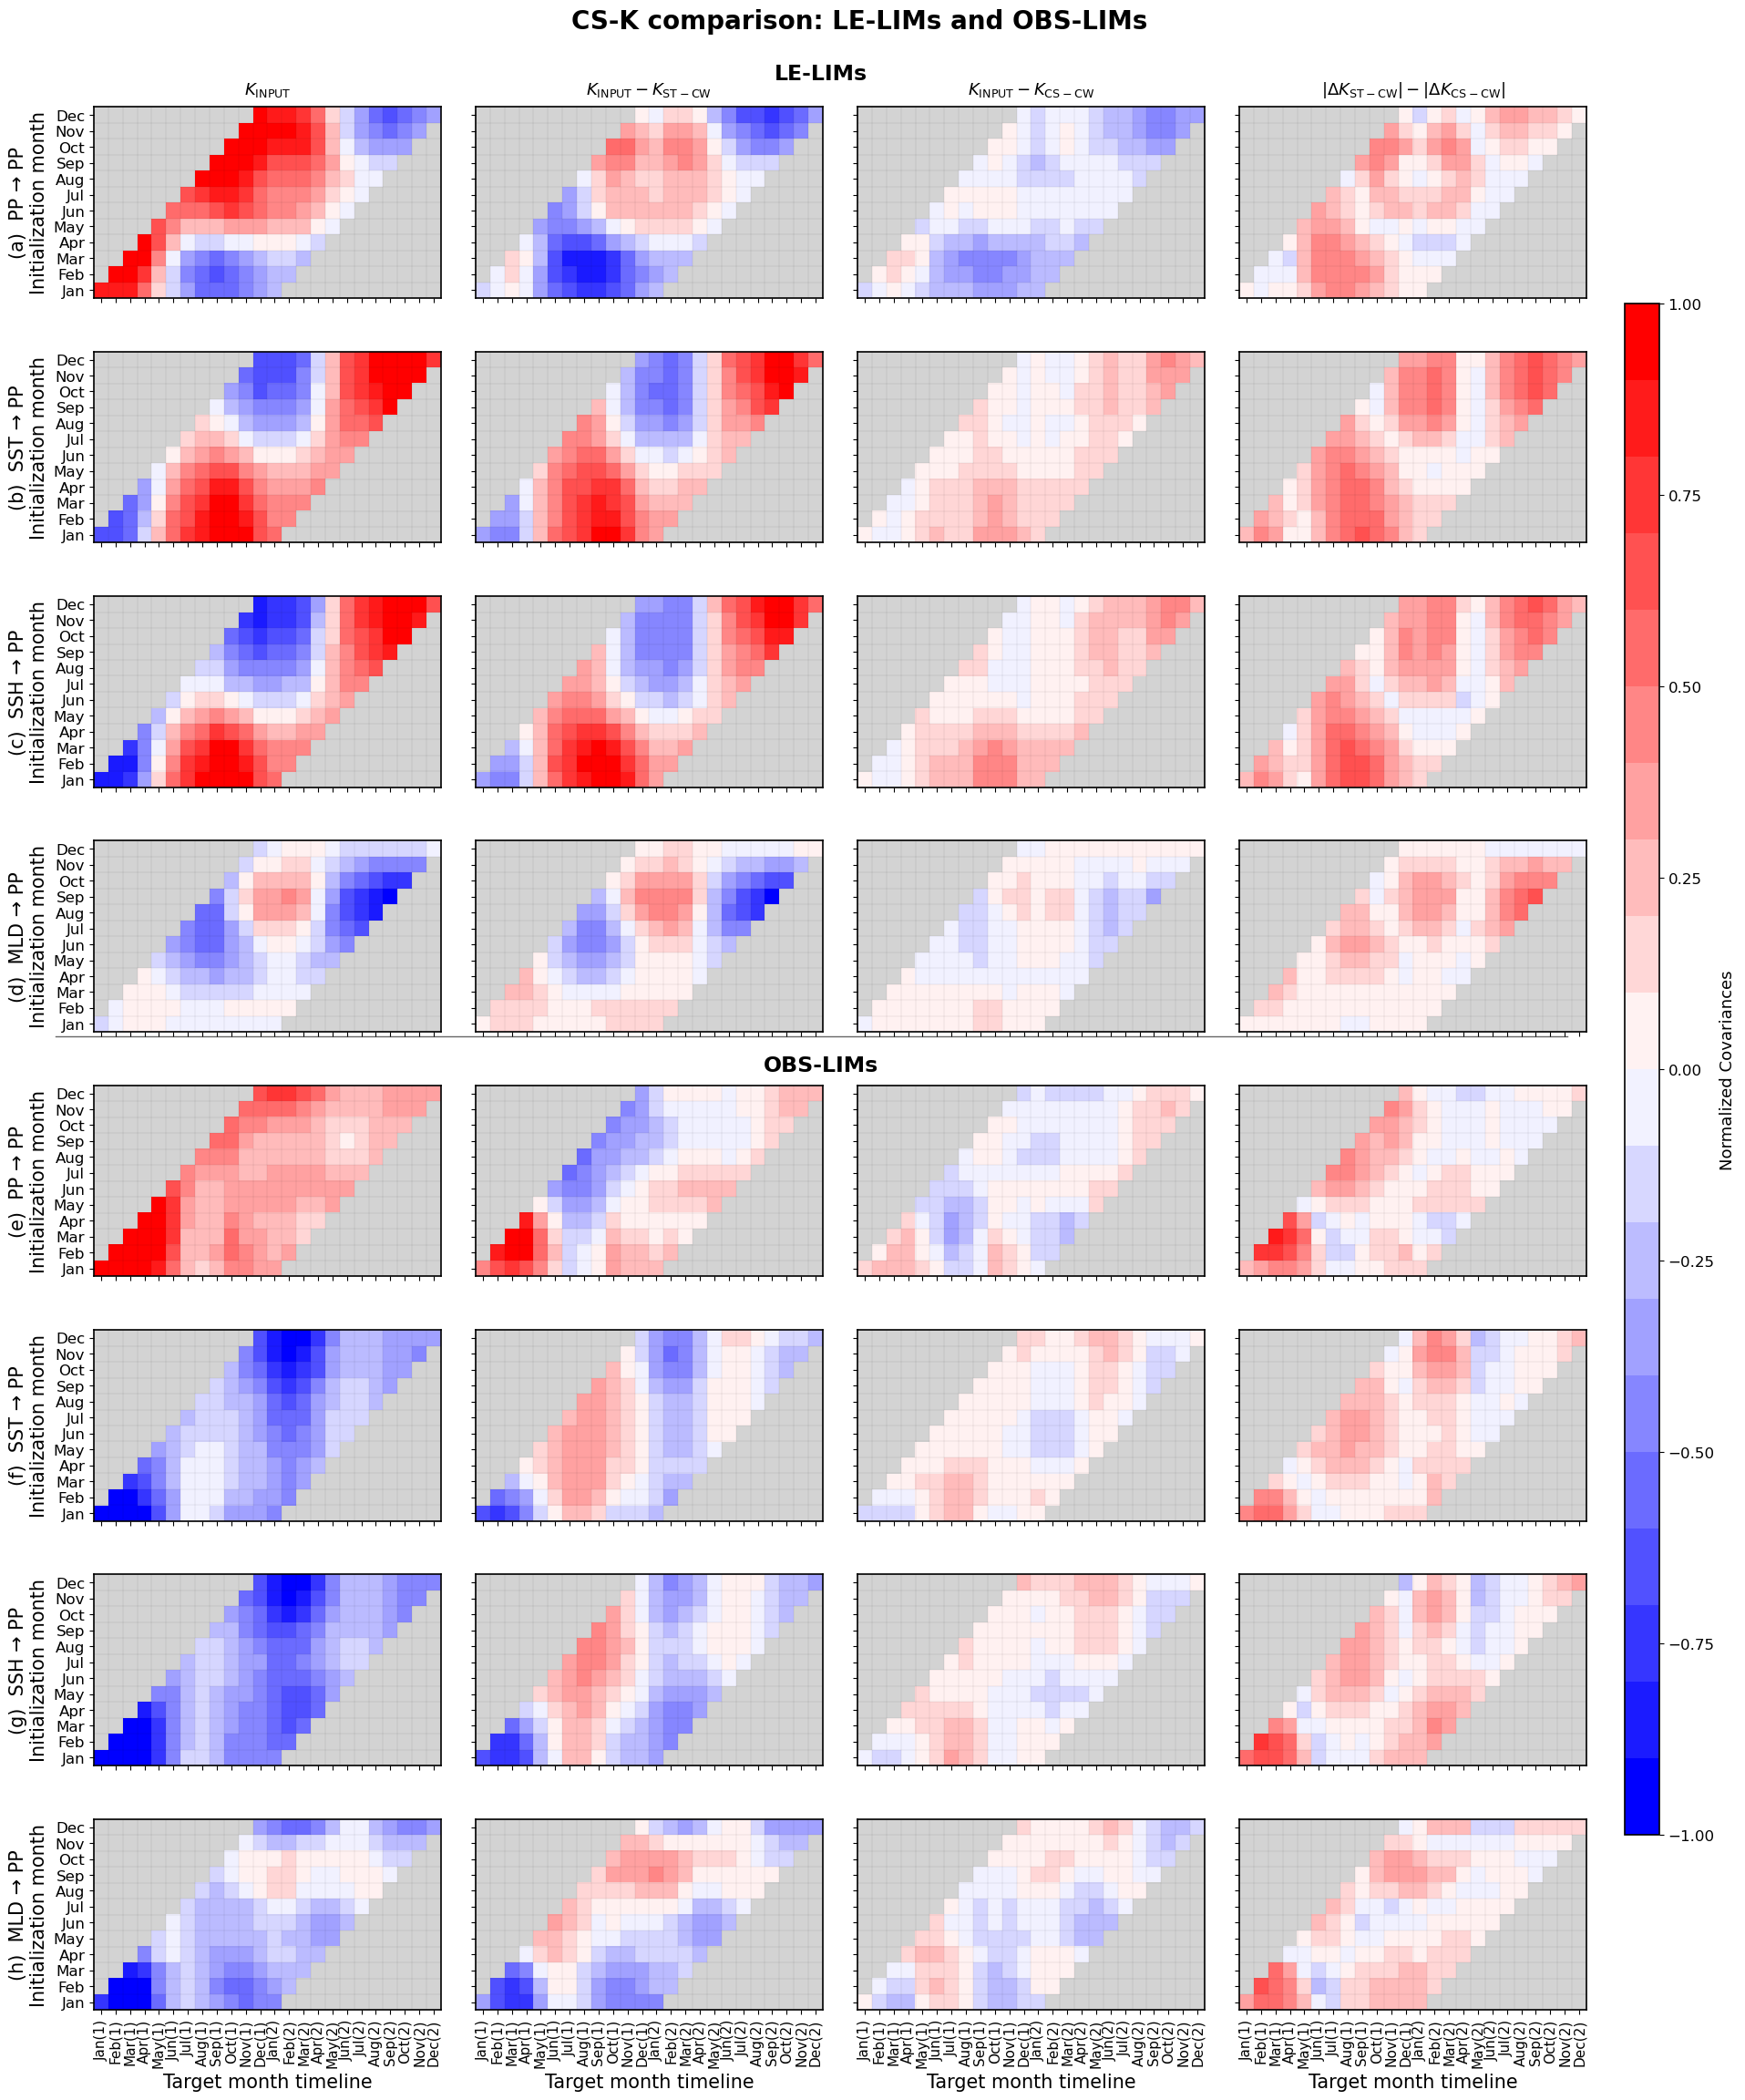

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl


# ============================================================
# 0. Plot settings
# ============================================================

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})


# ============================================================
# 1. Basic settings
# ============================================================

ds = ds_k

state_indices = {
    "PP": 0,
    "SST": 1,
    "SSH": 2,
    "MLD": 3,
}

plot_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
    ("SST", "SST"),
    ("SSH", "SSH"),
    ("MLD", "MLD"),
]

# ---- choose 4 rows to display ----
selected_pairs = [
    ("PP",  "PP"),
    ("SST", "PP"),
    ("SSH", "PP"),
    ("MLD", "PP"),
]
# 만약 다른 4개를 원하면 여기만 바꾸면 됨.

pair_keys = [f"{p}->{t}" for p, t in plot_pairs]
selected_keys = [f"{p}->{t}" for p, t in selected_pairs]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

n_month = 12
lead_dim_candidates = ["lead", "lead_index", "lag", "tau"]
MAX_LEAD_MONTH = 12


# ============================================================
# 2. Helper functions
# ============================================================

def find_lead_dim(da):
    for dim in lead_dim_candidates:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims={da.dims}")


def mean_over_ensemble(da):
    for dim in ["ens", "ens_LE", "ensemble", "member"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    return da


def check_var_exists(ds, varname):
    if varname not in ds:
        k_vars = [v for v in ds.data_vars if v.startswith("K_")]
        raise ValueError(
            f"{varname} not found in dataset.\n"
            f"Available K variables are:\n{k_vars}"
        )


def get_month_lead_matrix(ds, k_var, target_idx, predictor_idx):
    """
    Extract K[target, predictor] as [month, lead].

    If the variable has no 'month' dimension, repeat the same
    [lead] vector for all 12 initialization months.
    """
    check_var_exists(ds, k_var)

    da = ds[k_var]
    da = mean_over_ensemble(da)

    if "state_i" not in da.dims or "state_j" not in da.dims:
        raise ValueError(f"state_i/state_j not found in {k_var}. dims={da.dims}")

    lead_dim = find_lead_dim(da)

    da_sel = (
        da
        .isel(state_i=target_idx, state_j=predictor_idx)
        .squeeze(drop=True)
    )

    if "month" in da_sel.dims:
        C = da_sel.transpose("month", lead_dim).values
    else:
        C_lead = da_sel.transpose(lead_dim).values
        C = np.tile(C_lead[None, :], (n_month, 1))

    return C


def shifted_target_matrix(C, max_lag):
    """
    Convert C[init_month, lead] into target-month aligned matrix.

    Output:
        skill[init_month, target_month_timeline]
    """
    W = max_lag + 12
    skill = np.full((12, W), np.nan)

    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :max_lag + 1]

    return skill


def make_target_month_labels(max_lag):
    labels = []
    year = 1

    for i in range(max_lag + 12):
        mo = i % 12
        if i > 0 and mo == 0:
            year += 1
        labels.append(f"{month_names[mo]}({year})")

    return labels


def build_panel_data(ds, k_input, k_st_cw, k_cs_cw, plot_pairs):
    """
    Build panel_data dictionary for one experiment set (LE or OBS).
    """
    C_input_all = {}
    C_stcw_all  = {}
    C_cscw_all  = {}

    for predictor_name, target_name in plot_pairs:
        predictor_idx = state_indices[predictor_name]
        target_idx    = state_indices[target_name]
        pair_key = f"{predictor_name}->{target_name}"

        C_input_all[pair_key] = get_month_lead_matrix(
            ds, k_input, target_idx, predictor_idx
        )
        C_stcw_all[pair_key] = get_month_lead_matrix(
            ds, k_st_cw, target_idx, predictor_idx
        )
        C_cscw_all[pair_key] = get_month_lead_matrix(
            ds, k_cs_cw, target_idx, predictor_idx
        )

    # common lead length
    pair_keys_local = [f"{p}->{t}" for p, t in plot_pairs]

    n_lead_available = min(
        *[C_input_all[key].shape[1] for key in pair_keys_local],
        *[C_stcw_all[key].shape[1]  for key in pair_keys_local],
        *[C_cscw_all[key].shape[1]  for key in pair_keys_local],
    )

    n_lead = min(MAX_LEAD_MONTH + 1, n_lead_available)
    max_lag = n_lead - 1

    for key in pair_keys_local:
        C_input_all[key] = C_input_all[key][:, :n_lead]
        C_stcw_all[key]  = C_stcw_all[key][:, :n_lead]
        C_cscw_all[key]  = C_cscw_all[key][:, :n_lead]

    panel_data = {}

    for key in pair_keys_local:
        input_k = C_input_all[key]
        diff_stcw = C_input_all[key] - C_stcw_all[key]
        diff_cscw = C_input_all[key] - C_cscw_all[key]
        diff_abs  = np.abs(diff_stcw) - np.abs(diff_cscw)

        panel_data[key] = [
            input_k,
            diff_stcw,
            diff_cscw,
            diff_abs,
        ]

    labels = make_target_month_labels(max_lag)

    return panel_data, labels, max_lag


# ============================================================
# 3. Build LE / OBS panel data
# ============================================================

panel_titles = [
    r"$K_{\mathrm{INPUT}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{ST-CW}}$",
    r"$K_{\mathrm{INPUT}} - K_{\mathrm{CS-CW}}$",
    r"$|\Delta K_{\mathrm{ST-CW}}| - |\Delta K_{\mathrm{CS-CW}}|$",
]

# LE
panel_data_le, labels_le, max_lag_le = build_panel_data(
    ds,
    k_input="K_CS_OBS_LE",
    k_st_cw="K_ST_CW_LE",
    k_cs_cw="K_CS_CW_LE",
    plot_pairs=plot_pairs,
)

# OBS
panel_data_obs, labels_obs, max_lag_obs = build_panel_data(
    ds,
    k_input="K_CS_OBS_OBS",
    k_st_cw="K_ST_CW_OBS",
    k_cs_cw="K_CS_CW_OBS",
    plot_pairs=plot_pairs,
)

# Safety check
if labels_le != labels_obs:
    raise ValueError("LE and OBS target-month labels do not match.")
if max_lag_le != max_lag_obs:
    raise ValueError("LE and OBS max_lag do not match.")

labels = labels_le
max_lag = max_lag_le


# ============================================================
# 4. Colormap
# ============================================================

nColors = 20

base_colors = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 0],
])

x_base = np.linspace(-1, 1, 3)
x_new = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")


# ============================================================
# 5. Color range
# ============================================================

vlim = 1.0


# ============================================================
# 6. Combine rows: upper 4 = LE, lower 4 = OBS
# ============================================================

combined_rows = []

# (a)~(d): LE
for p, t in selected_pairs:
    combined_rows.append({
        "group": "LE-LIMs",
        "pair": (p, t),
        "key": f"{p}->{t}",
    })

# (e)~(h): OBS
for p, t in selected_pairs:
    combined_rows.append({
        "group": "OBS-LIMs",
        "pair": (p, t),
        "key": f"{p}->{t}",
    })

row_letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]


# ============================================================
# 7. Plot: 8 rows x 4 columns
# ============================================================

n_row = len(combined_rows)   # 8
n_col = 4

fig, axes = plt.subplots(
    n_row, n_col,
    figsize=(21, 24),
    sharex=True,
    sharey=True,
)

fig.subplots_adjust(
    left=0.10,
    right=0.88,
    bottom=0.06,
    top=0.93,
    wspace=0.10,
    hspace=0.28,
)

im_input = None
im_diff = None

for irow, row_info in enumerate(combined_rows):

    predictor_name, target_name = row_info["pair"]
    key = row_info["key"]

    if row_info["group"] == "LE-LIMs":
        this_panel_data = panel_data_le[key]
    else:
        this_panel_data = panel_data_obs[key]

    for icol in range(n_col):

        ax = axes[irow, icol]

        Cplot = this_panel_data[icol]
        skill = shifted_target_matrix(Cplot, max_lag)
        masked = np.ma.masked_invalid(skill)

        vmin, vmax = -vlim, vlim

        im = ax.imshow(
            masked,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=-vlim,
            vmax=vlim,
            interpolation="none",
        )

        if icol == 0:
            im_input = im
        else:
            im_diff = im

        # Column titles on first row only
        if irow == 0:
            ax.set_title(
                panel_titles[icol],
                fontsize=13,
                fontweight="bold",
                pad=10,
            )

        # Row label only on first column
        if icol == 0:
            ax.set_ylabel(
                f"{row_letters[irow]}  {predictor_name} → {target_name}\nInitialization month"
            )

        # Y ticks
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(month_names)

        # Grid lines
        ax.set_yticks(np.arange(-0.5, 12, 1), minor=True)
        ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)

        ax.grid(
            which="minor",
            color="k",
            linestyle="-",
            linewidth=0.25,
            alpha=0.20,
        )
        ax.tick_params(which="minor", bottom=False, left=False)

        # X ticks only on bottom row
        if irow == n_row - 1:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=90)
            ax.set_xlabel("Target month timeline")
        else:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels([])


# ============================================================
# 8. Group titles
# ============================================================

# Above rows 1-4
fig.text(
    0.48, 0.945,
    "LE-LIMs",
    ha="center", va="center",
    fontsize=17, fontweight="bold"
)

# Above rows 5-8
fig.text(
    0.48, 0.492,
    "OBS-LIMs",
    ha="center", va="center",
    fontsize=17, fontweight="bold"
)

# optional separator line between LE and OBS blocks
fig.lines.append(
    plt.Line2D(
        [0.08, 0.87], [0.505, 0.505],
        transform=fig.transFigure,
        color="k", linewidth=1.0, alpha=0.6
    )
)


# ============================================================
# 9. Colorbars
# ============================================================

# INPUT colorbar
cax1 = fig.add_axes([0.90, 0.14, 0.018, 0.70])
cbar1 = fig.colorbar(im_input, cax=cax1)
cbar1.set_label("Normalized Covariances", fontsize=13)

# # Difference colorbar
# cax2 = fig.add_axes([0.90, 0.14, 0.018, 0.30])
# cbar2 = fig.colorbar(im_diff, cax=cax2, extend="both")
# cbar2.set_label("Difference", fontsize=13)


# ============================================================
# 10. Suptitle
# ============================================================

fig.suptitle(
    "CS-K comparison: LE-LIMs and OBS-LIMs",
    fontsize=20,
    fontweight="bold",
    y=0.975,
)

plt.show()